# Applying the Trained Models

This notebook applies trained PINN-MSCNN models to the MODEST Hinode/SP dataset and performs comprehensive analysis including:
- Model loading and inference with uncertainty quantification (Monte Carlo Dropout)
- Spatial maps comparison (predictions vs ground truth)
- Statistical analysis (correlation, RMSE, bias)
- Vertical atmospheric profile comparison
- Multi-model comparison (no physics, WFA only, all physics)
- Error analysis across optical depths

## 0. Prerequisites

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import torch
import astropy.units as u
from pathlib import Path
import sys
from scipy.stats import pearsonr
import pandas as pd
from typing import Dict, Tuple, Optional

# Add parent directories to path
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN")
from utils.modest_data import ModestData
from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.normalizer import MhdNormalizer, StokesNormalizer

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✓ All imports successful")

✓ All imports successful


## 1. Load MODEST Data

In [2]:
data_path = Path("/scratchsan/observatorio/juagudeloo/data")

In [3]:
modest = ModestData()
modest.load_all(apply_mask=False)
print("✓ MODEST data loaded successfully")
print(f"  Continuum shape: {modest.continuum.shape}")
print(f"  Stokes I shape: {modest.obs_stokes['I'].shape}")
print(f"  Wavelength points: {len(modest.wl)}")

✓ MODEST data loaded successfully
  Continuum shape: (390, 858)
  Stokes I shape: (390, 858, 112)
  Wavelength points: 112


In [4]:
# Load normalizers
mhd_normalizer = MhdNormalizer()
mhd_normalizer.load(data_path / "normalization_stats/mhd_normalization.json")

stokes_normalizer = StokesNormalizer()
stokes_normalizer.load(data_path / "normalization_stats/stokes_normalization.json")

# Normalize Stokes data
normalized_stokes = stokes_normalizer.transform(modest.obs_stokes)
print("✓ Normalizers loaded and Stokes data normalized")

Per-τ normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/mhd_normalization.json
Optical depth levels: 21
Stokes normalization statistics loaded from /scratchsan/observatorio/juagudeloo/data/normalization_stats/stokes_normalization.json
✓ Normalizers loaded and Stokes data normalized


## 2. Visualize FOV and Disk Center

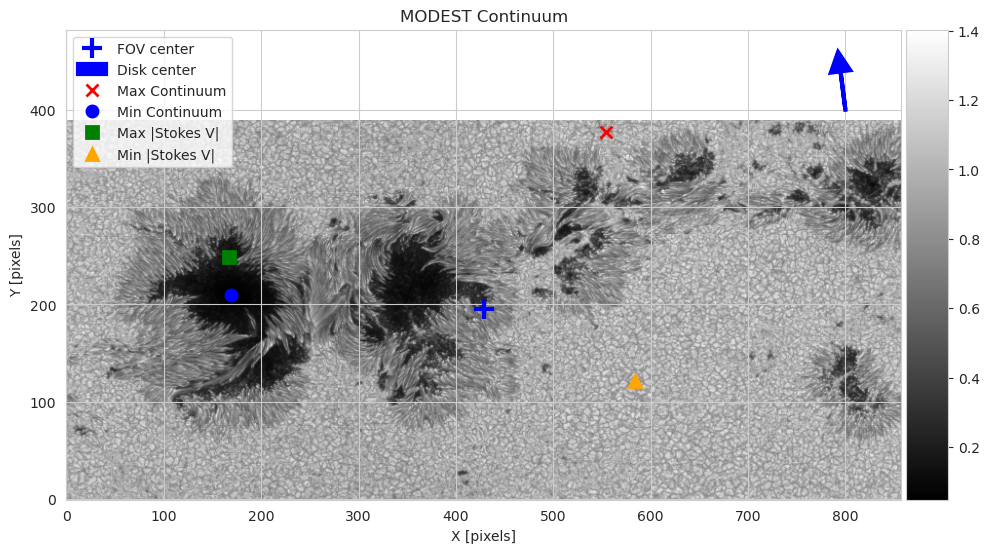

In [5]:
y_center_fov_arcsec = -126.0
x_center_fov_arcsec = 16.0
pixel_scale = 0.32
x_center_fov_pixel = modest.continuum.shape[1] / 2
y_center_fov_pixel = modest.continuum.shape[0] / 2
x_disk_offset_arcsec = 0 - x_center_fov_arcsec
y_disk_offset_arcsec = 0 - y_center_fov_arcsec
x_disk_offset_pixels = x_disk_offset_arcsec / pixel_scale
y_disk_offset_pixels = y_disk_offset_arcsec / pixel_scale
x_disk_center = x_center_fov_pixel + x_disk_offset_pixels
y_disk_center = y_center_fov_pixel + y_disk_offset_pixels
arrow_start_x = 800
arrow_start_y = 400
arrow_dx = x_disk_offset_pixels/10
arrow_dy = y_disk_offset_pixels/10

modest.plot_continuum(
    x_center_fov_pixel=x_center_fov_pixel,
    y_center_fov_pixel=y_center_fov_pixel,
    disk_center=(x_disk_center, y_disk_center),
    arrow_params=(arrow_start_x, arrow_start_y, arrow_dx, arrow_dy)
)

## 3. Load and Compare Multiple Models

We'll load three models trained with different physics regularization:
1. **No Physics**: Pure supervised learning
2. **WFA Only**: Weak-Field Approximation for B_LOS
3. **All Physics**: WFA + Gradient Smoothness

In [6]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model configurations to compare
model_configs = {
    'no_physics': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation_60_to_100/no_physics/final_model.pth',
        'use_physics': None,
        'lambda_wfa': 0.0,
        'lambda_doppler': 0.0,
        'lambda_physics': 0.0,
        'label': 'No Physics',
        'color': 'blue'
    },
    'wfa_only': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation/wfa_only/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_physics': 0.0,
        'label': 'WFA Only',
        'color': 'orange'
    },
    'all_physics': {
        'path': '/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/output/experiments/physics_regularization_ablation/all_physics_terms/final_model.pth',
        'use_physics': 'wfa',
        'lambda_wfa': 0.01,
        'lambda_doppler': 0.0,
        'lambda_physics': 0.02,
        'label': 'All Physics',
        'color': 'green'
    }
}

def load_model(config: Dict) -> PhysicsInformedMSCNN:
    """Load a trained PINN-MSCNN model."""
    model = PhysicsInformedMSCNN(
        scales=[1, 2, 3],
        in_channels=2,
        c1_filters=16,
        c2_filters=32,
        kernel_size=5,
        pool_size=2,
        n_linear_layers=4,
        output_features=3*21,
        input_length=112,
        dropout_rate=0.2,
        use_physics=config['use_physics'],
        lambda_wfa=config['lambda_wfa'],
        lambda_doppler=config['lambda_doppler'],
        lambda_physics=config['lambda_physics'],
    ).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(config['path'], map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model

# Load all models
models = {}
for name, config in model_configs.items():
    print(f"Loading {config['label']}...")
    models[name] = load_model(config)
    print(f"  ✓ Model loaded successfully")
    if 'test_metrics' in torch.load(config['path'], map_location='cpu'):
        metrics = torch.load(config['path'], map_location='cpu')['test_metrics']
        print(f"  Training metrics: B_LOS RRMSE={metrics.get('blos_rrmse_tau_avg', 'N/A'):.4f}, "
              f"V_LOS RRMSE={metrics.get('vlos_rrmse_tau_avg', 'N/A'):.4f}")

print(f"\n✓ All {len(models)} models loaded")

Using device: cuda
Loading No Physics...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3127
Loading WFA Only...
  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3247
Loading All Physics...


  ✓ Model loaded successfully
  Training metrics: B_LOS RRMSE=inf, V_LOS RRMSE=1.3248

✓ All 3 models loaded


## 4. Prepare Input Data

In [7]:
# Prepare input tensor
I_t = normalized_stokes["I"]
V_t = normalized_stokes["V"]
inputs = np.stack([I_t, V_t], axis=2)  # Shape: (H, W, 2, nλ)
H, W, Nstokes, Nlambda = inputs.shape

# Convert to torch tensor
inputs_tensor = torch.tensor(inputs, dtype=torch.float32).permute(0, 1, 3, 2)  # (H, W, nλ, 2)
inputs_tensor = inputs_tensor.reshape(H*W, Nstokes, Nlambda).to(device)  # (H*W, 2, nλ)

print(f"Input tensor shape: {inputs_tensor.shape}")
print(f"Total pixels: {H*W:,}")

Input tensor shape: torch.Size([334620, 2, 112])
Total pixels: 334,620


## 5. Run Inference with Uncertainty Quantification

Using Monte Carlo Dropout (30 stochastic forward passes) to estimate prediction uncertainty.

In [8]:
def run_inference_with_uncertainty(
    model: PhysicsInformedMSCNN,
    inputs: torch.Tensor,
    mhd_normalizer: MhdNormalizer,
    batch_size: int = 512,
    stochastic_steps: int = 30,
    H: int = None,
    W: int = None,
    n_heights: int = 21
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    """
    Run model inference with uncertainty quantification.
    
    Returns
    -------
    mean_atm : Dict[str, np.ndarray]
        Mean predictions (H, W, n_heights) for T, Vz, Bz
    std_atm : Dict[str, np.ndarray]
        Standard deviations (H, W, n_heights) for T, Vz, Bz
    """
    model.eval()
    all_stochastic_predictions = []
    
    print("Running inference with Monte Carlo Dropout...")
    with torch.no_grad():
        for i in range(0, len(inputs), batch_size):
            batch = inputs[i:i+batch_size]
            # Returns shape: (stochastic_steps, batch_size, 63)
            batch_predictions = model(batch, stocastic_generation=True, stocastic_steps=stochastic_steps)
            all_stochastic_predictions.append(batch_predictions.cpu())
            
            if (i // batch_size) % 100 == 0:
                print(f"  Processed {i:,}/{len(inputs):,} pixels ({100*i/len(inputs):.1f}%)")
    
    # Concatenate: (stochastic_steps, H*W, 63)
    stochastic_predictions = torch.cat(all_stochastic_predictions, dim=1)
    print(f"  Stochastic predictions shape: {stochastic_predictions.shape}")
    
    # Denormalize
    n_stochastic = stochastic_predictions.shape[0]
    n_pixels = stochastic_predictions.shape[1]
    predictions_reshaped = stochastic_predictions.reshape(-1, 63).numpy()
    
    denorm_dict = mhd_normalizer.inverse_transform(
        predictions_reshaped, param_order=['T', 'Vz', 'Bz']
    )
    
    # Reshape to (stochastic_steps, H*W, n_heights) for each parameter
    denorm_stochastic = {}
    for param in ['T', 'Vz', 'Bz']:
        denorm_stochastic[param] = denorm_dict[param].reshape(n_stochastic, n_pixels, n_heights)
    
    # Compute statistics
    mean_atm = {}
    std_atm = {}
    for param in ['T', 'Vz', 'Bz']:
        mean_atm[param] = np.mean(denorm_stochastic[param], axis=0).reshape(H, W, n_heights)
        std_atm[param] = np.std(denorm_stochastic[param], axis=0).reshape(H, W, n_heights)
    
    print("  ✓ Inference complete")
    return mean_atm, std_atm

# Run inference for all models
all_predictions = {}
print("\n" + "="*70)
for model_name, model in models.items():
    print(f"\nRunning inference for {model_configs[model_name]['label']}...")
    mean_atm, std_atm = run_inference_with_uncertainty(
        model, inputs_tensor, mhd_normalizer,
        batch_size=512, stochastic_steps=30,
        H=H, W=W, n_heights=21
    )
    all_predictions[model_name] = {
        'mean': mean_atm,
        'std': std_atm,
        'label': model_configs[model_name]['label'],
        'color': model_configs[model_name]['color']
    }
    print(f"  T range: {mean_atm['T'].min():.1f} - {mean_atm['T'].max():.1f} K")
    print(f"  Vz range: {mean_atm['Vz'].min():.2f} - {mean_atm['Vz'].max():.2f} km/s")
    print(f"  Bz range: {mean_atm['Bz'].min():.2f} - {mean_atm['Bz'].max():.2f} G")

print("\n" + "="*70)
print("✓ All model inferences complete")



Running inference for No Physics...
Running inference with Monte Carlo Dropout...


  Processed 0/334,620 pixels (0.0%)
  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/334,620 pixels (91.8%)
  Stochastic predictions shape: torch.Size([30, 334620, 63])


/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/normalizer.py:189: RuntimeWarning: overflow encountered in power
  denorm_tau = sign * (10 ** np.abs(pred_log) - 1.0)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


  ✓ Inference complete
  T range: -28748.2 - 12639.7 K
  Vz range: -76.95 - 51.09 km/s
  Bz range: -15901952862237515768420892672.00 - inf G

Running inference for WFA Only...
Running inference with Monte Carlo Dropout...
  Processed 0/334,620 pixels (0.0%)
  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Processed 204,800/334,620 pixels (61.2%)
  Processed 256,000/334,620 pixels (76.5%)
  Processed 307,200/334,620 pixels (91.8%)
  Stochastic predictions shape: torch.Size([30, 334620, 63])
  ✓ Inference complete
  T range: -17114.5 - 11216.0 K
  Vz range: -24.52 - 29.34 km/s
  Bz range: -110888333947889584368588087623680.00 - 582726988767352758206464.00 G

Running inference for All Physics...
Running inference with Monte Carlo Dropout...
  Processed 0/334,620 pixels (0.0%)
  Processed 51,200/334,620 pixels (15.3%)
  Processed 102,400/334,620 pixels (30.6%)
  Processed 153,600/334,620 pixels (45.9%)
  Proce

## 6. Analysis Functions

In [18]:
def plot_prediction_comparison(
    mean_atm: dict,
    std_atm: dict,
    ground_truth: dict,
    mag_to_plot: str = "T",
    od_to_plot: float = 0.0,
    logtau: np.ndarray = None,
    model_label: str = "Model",
    figsize: tuple = (14, 18)
):
    """
    Plot comprehensive comparison between predicted mean, ground truth, and uncertainty.
    
    Parameters
    ----------
    mean_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing mean predictions (H, W, n_heights)
    std_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing standard deviations (H, W, n_heights)
    ground_truth : dict
        Dictionary with keys ['T', 'Vlos', 'Blos'] containing ground truth data (n_heights, H, W)
    mag_to_plot : str
        Parameter to plot: 'T', 'Vz', or 'Bz'
    od_to_plot : float
        Optical depth value to plot
    logtau : np.ndarray, optional
        Array of log(tau) values
    model_label : str
        Label for the model
    figsize : tuple
        Figure size
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    logtau_idx = np.argmin(np.abs(logtau - od_to_plot))
    
    # Mapping dictionaries
    title_map = {"T": "Temperature", "Vz": "Line-of-sight Velocity", "Bz": "Line-of-sight Magnetic Field"}
    units_map = {"T": "K", "Vz": "km/s", "Bz": "G"}
    modest_key_mapping = {"T": "T", "Vz": "Vlos", "Bz": "Blos"}
    color_mapping = {"T": "inferno", "Vz": "bwr_r", "Bz": "PiYG"}
    uncertainty_cmap = {"T": "YlOrRd", "Vz": "viridis", "Bz": "viridis"}
    
    # Get data - use logtau_idx for ground truth
    pred_mean = mean_atm[mag_to_plot][:, :, logtau_idx]
    pred_std = std_atm[mag_to_plot][:, :, logtau_idx]
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_to_plot]
    
    # Compute difference
    difference = pred_mean - gt
    
    # Compute color limits
    q0, q99 = np.percentile(gt, [1, 99])
    if mag_to_plot in ["Vz", "Bz"]:
        vmax = max(np.abs(q0), np.abs(q99))
        vmin = -vmax
    else:
        vmin, vmax = q0, q99
    
    diff_max = np.percentile(np.abs(difference), 99)
    diff_vmin, diff_vmax = -diff_max, diff_max
    
    # Compute metrics
    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    corr, p_value = pearsonr(pred_mean.flatten(), gt.flatten())
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    ax = [fig.add_subplot(gs[i, j]) for i in range(3) for j in range(2)]
    
    fig.suptitle(f"{model_label}: {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}",
                 fontsize=18, fontweight='bold')
    
    # 1. Predicted Mean
    im0 = ax[0].imshow(pred_mean, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[0])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im0, cax=cax, label=units_map[mag_to_plot])
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[0].set_title("Predicted Mean", fontsize=14, fontweight='bold')
    
    # 2. Ground Truth
    im1 = ax[1].imshow(gt, cmap=color_mapping[mag_to_plot], vmax=vmax, vmin=vmin)
    divider = make_axes_locatable(ax[1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im1, cax=cax, label=units_map[mag_to_plot])
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_title("Ground Truth", fontsize=14, fontweight='bold')
    
    # 3. Difference
    im2 = ax[2].imshow(difference, cmap='RdBu_r', vmax=diff_vmax, vmin=diff_vmin)
    divider = make_axes_locatable(ax[2])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im2, cax=cax, label=f"Δ {units_map[mag_to_plot]}")
    ax[2].set_xticks([])
    ax[2].set_yticks([])
    ax[2].set_title(f"Difference (Pred - GT)\nRMSE: {rmse:.2f} | Bias: {bias:.2f} {units_map[mag_to_plot]}",
                   fontsize=14, fontweight='bold')
    
    # 4. Predicted Std Dev
    im3 = ax[3].imshow(pred_std, cmap=uncertainty_cmap[mag_to_plot])
    divider = make_axes_locatable(ax[3])
    cax2 = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(im3, cax=cax2, label=f"σ {units_map[mag_to_plot]}")
    ax[3].set_xticks([])
    ax[3].set_yticks([])
    ax[3].set_title(f"Predicted Std Dev\nMean σ: {np.mean(pred_std):.2f} | Median σ: {np.median(pred_std):.2f}",
                   fontsize=14, fontweight='bold')
    
    # 5. Distribution Comparison
    ax[4].hist(pred_mean.flatten(), bins=100, color='red', edgecolor='darkred',
              alpha=0.6, label="Predicted Mean", density=True)
    ax[4].hist(gt.flatten(), bins=100, color='blue', edgecolor='darkblue',
              alpha=0.5, label="Ground Truth", density=True)
    ax[4].set_xlim(vmin, vmax)
    ax[4].set_xlabel(units_map[mag_to_plot], fontsize=12)
    ax[4].set_ylabel("Density", fontsize=12)
    ax[4].legend(fontsize=11)
    ax[4].set_title("Distribution Comparison", fontsize=14, fontweight='bold')
    ax[4].grid(alpha=0.3)
    
    # 6. Scatter Plot
    n_samples = min(10000, pred_mean.size)
    indices = np.random.choice(pred_mean.size, n_samples, replace=False)
    gt_flat = gt.flatten()[indices]
    pred_flat = pred_mean.flatten()[indices]
    
    ax[5].scatter(gt_flat, pred_flat, alpha=0.3, s=2, c='black', edgecolors='none')
    lims = [np.min([ax[5].get_xlim(), ax[5].get_ylim()]),
            np.max([ax[5].get_xlim(), ax[5].get_ylim()])]
    ax[5].plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
    ax[5].set_xlim(lims)
    ax[5].set_ylim(lims)
    ax[5].set_xlabel(f"Ground Truth ({units_map[mag_to_plot]})", fontsize=12)
    ax[5].set_ylabel(f"Predicted ({units_map[mag_to_plot]})", fontsize=12)
    ax[5].set_title(f"Scatter Plot\nPearson R = {corr:.4f} (p < {p_value:.1e})",
                   fontsize=14, fontweight='bold')
    ax[5].legend(fontsize=11, loc='lower right')
    ax[5].grid(alpha=0.3)
    ax[5].set_aspect('equal', adjustable='box')
    ax[5].text(0.05, 0.95, f"R = {corr:.4f}\nN = {n_samples:,}",
              transform=ax[5].transAxes, fontsize=11, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"Summary for {model_label}: {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}")
    print(f"{'='*60}")
    print(f"Pearson R:   {corr:.4f} (p-value: {p_value:.2e})")
    print(f"RMSE:        {rmse:.3f} {units_map[mag_to_plot]}")
    print(f"Bias:        {bias:.3f} {units_map[mag_to_plot]}")
    print(f"Mean σ:      {np.mean(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"Median σ:    {np.median(pred_std):.3f} {units_map[mag_to_plot]}")
    print(f"{'='*60}\n")


def compare_models_at_optical_depth(
    all_predictions: Dict,
    ground_truth: dict,
    mag_to_plot: str = "T",
    od_to_plot: float = 0.0,
    logtau: np.ndarray = None,
    figsize: tuple = (18, 12)
):
    """
    Compare multiple models side-by-side at a specific optical depth.
    
    Parameters
    ----------
    all_predictions : Dict
        Dictionary of {model_name: {'mean': ..., 'std': ..., 'label': ..., 'color': ...}}
    ground_truth : dict
        Ground truth SPINOR atmosphere
    mag_to_plot : str
        Parameter to plot: 'T', 'Vz', or 'Bz'
    od_to_plot : float
        Optical depth value
    logtau : np.ndarray, optional
        Optical depth grid
    figsize : tuple
        Figure size
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    logtau_idx = np.argmin(np.abs(logtau - od_to_plot))
    
    title_map = {"T": "Temperature", "Vz": "Line-of-sight Velocity", "Bz": "Line-of-sight Magnetic Field"}
    units_map = {"T": "K", "Vz": "km/s", "Bz": "G"}
    modest_key_mapping = {"T": "T", "Vz": "Vlos", "Bz": "Blos"}
    color_mapping = {"T": "hot", "Vz": "bwr_r", "Bz": "PiYG"}
    
    # Use logtau_idx instead of od_to_plot
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_to_plot]
    q0, q99 = np.percentile(gt, [1, 99])
    
    if mag_to_plot in ["Vz", "Bz"]:
        vmax = max(np.abs(q0), np.abs(q99))
        vmin = -vmax
    else:
        vmin, vmax = q0, q99
    
    n_models = len(all_predictions)
    fig, axes = plt.subplots(2, n_models + 1, figsize=figsize)
    
    # Ground Truth (first column)
    im_gt = axes[0, 0].imshow(gt, cmap=color_mapping[mag_to_plot], vmin=vmin, vmax=vmax)
    axes[0, 0].set_title("Ground Truth", fontsize=12, fontweight='bold')
    axes[0, 0].set_xticks([])
    axes[0, 0].set_yticks([])
    divider = make_axes_locatable(axes[0, 0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im_gt, cax=cax, label=units_map[mag_to_plot])
    
    # Distribution plot for GT
    axes[1, 0].hist(gt.flatten(), bins=50, color='gray', alpha=0.7, label='GT', density=True)
    axes[1, 0].set_xlabel(units_map[mag_to_plot])
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].set_xlim(vmin, vmax)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Models
    for i, (model_name, pred_data) in enumerate(all_predictions.items(), start=1):
        mean_atm = pred_data['mean']
        pred_mean = mean_atm[mag_to_plot][:, :, logtau_idx]
        difference = pred_mean - gt
        rmse = np.sqrt(np.mean(difference**2))
        corr, _ = pearsonr(pred_mean.flatten(), gt.flatten())
        
        # Spatial map
        im = axes[0, i].imshow(pred_mean, cmap=color_mapping[mag_to_plot], vmin=vmin, vmax=vmax)
        axes[0, i].set_title(f"{pred_data['label']}\nRMSE={rmse:.2f}, R={corr:.3f}",
                            fontsize=12, fontweight='bold')
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        divider = make_axes_locatable(axes[0, i])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        fig.colorbar(im, cax=cax, label=units_map[mag_to_plot])
        
        # Distribution
        axes[1, i].hist(pred_mean.flatten(), bins=50, color=pred_data['color'],
                       alpha=0.7, label=pred_data['label'], density=True)
        axes[1, i].hist(gt.flatten(), bins=50, color='gray', alpha=0.3,
                       label='GT', density=True)
        axes[1, i].set_xlabel(units_map[mag_to_plot])
        axes[1, i].set_ylabel("Density")
        axes[1, i].set_xlim(vmin, vmax)
        axes[1, i].legend()
        axes[1, i].grid(alpha=0.3)
    
    fig.suptitle(f"Model Comparison: {title_map[mag_to_plot]} at log(τ)={logtau[logtau_idx]:.1f}",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compute_metrics_across_optical_depths(
    all_predictions: Dict,
    ground_truth: dict,
    logtau: np.ndarray = None
) -> pd.DataFrame:
    """
    Compute RMSE, bias, and correlation for all models across optical depths.
    
    Returns
    -------
    df : pd.DataFrame
        Metrics table with columns: model, parameter, optical_depth, RMSE, bias, correlation
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    modest_key_mapping = {"T": "T", "Vz": "Vlos", "Bz": "Blos"}
    records = []
    
    for model_name, pred_data in all_predictions.items():
        for param in ['T', 'Vz', 'Bz']:
            for od_idx, od_val in enumerate(logtau):
                if od_val not in [-2.0, -0.8, 0.0]:  # Example optical depths to include
                    continue
                pred_mean = pred_data['mean'][param][:, :, od_idx]
                gt = ground_truth[modest_key_mapping[param]][od_val]
                
                diff = pred_mean - gt
                rmse = np.sqrt(np.mean(diff**2))
                bias = np.mean(diff)
                corr, _ = pearsonr(pred_mean.flatten(), gt.flatten())
                
                records.append({
                    'model': pred_data['label'],
                    'parameter': param,
                    'optical_depth': od_val,
                    'RMSE': rmse,
                    'bias': bias,
                    'correlation': corr
                })
    
    return pd.DataFrame(records)


def plot_metrics_vs_optical_depth(
    metrics_df: pd.DataFrame,
    figsize: tuple = (18, 5)
):
    """Plot RMSE, bias, and correlation as a function of optical depth."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    params = metrics_df['parameter'].unique()
    
    for param in params:
        df_param = metrics_df[metrics_df['parameter'] == param]
        
        # RMSE
        for model in df_param['model'].unique():
            df_model = df_param[df_param['model'] == model]
            axes[0].plot(df_model['optical_depth'], df_model['RMSE'],
                        'o-', label=f"{model} ({param})", markersize=4)
        
        # Bias
        for model in df_param['model'].unique():
            df_model = df_param[df_param['model'] == model]
            axes[1].plot(df_model['optical_depth'], df_model['bias'],
                        'o-', label=f"{model} ({param})", markersize=4)
        
        # Correlation
        for model in df_param['model'].unique():
            df_model = df_param[df_param['model'] == model]
            axes[2].plot(df_model['optical_depth'], df_model['correlation'],
                        'o-', label=f"{model} ({param})", markersize=4)
    
    axes[0].set_xlabel("log(τ)", fontsize=12)
    axes[0].set_ylabel("RMSE", fontsize=12)
    axes[0].set_title("RMSE vs Optical Depth", fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=8, loc='best')
    axes[0].grid(alpha=0.3)
    axes[0].invert_xaxis()
    
    axes[1].set_xlabel("log(τ)", fontsize=12)
    axes[1].set_ylabel("Bias", fontsize=12)
    axes[1].set_title("Bias vs Optical Depth", fontsize=14, fontweight='bold')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].legend(fontsize=8, loc='best')
    axes[1].grid(alpha=0.3)
    axes[1].invert_xaxis()
    
    axes[2].set_xlabel("log(τ)", fontsize=12)
    axes[2].set_ylabel("Pearson R", fontsize=12)
    axes[2].set_title("Correlation vs Optical Depth", fontsize=14, fontweight='bold')
    axes[2].axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
    axes[2].legend(fontsize=8, loc='best')
    axes[2].grid(alpha=0.3)
    axes[2].set_ylim([0.5, 1.0])
    axes[2].invert_xaxis()
    
    plt.tight_layout()
    plt.show()


def create_summary_table(metrics_df: pd.DataFrame, od_to_plot: float = 0.0) -> pd.DataFrame:
    """Create a summary table for a specific optical depth."""
    df_filtered = metrics_df[np.isclose(metrics_df['optical_depth'], od_to_plot, atol=0.05)]
    
    summary = df_filtered.pivot_table(
        index=['model', 'parameter'],
        values=['RMSE', 'bias', 'correlation'],
        aggfunc='mean'
    ).reset_index()
    
    return summary.sort_values(['parameter', 'model'])


print("✓ Analysis functions loaded")

✓ Analysis functions loaded


## 7. Single Model Analysis

Analyze each model individually at a specific optical depth.

In [10]:
modest.spinor_atm["T"].keys()

dict_keys([-2.0, -0.8, 0.0])

/tmp/ipykernel_1425124/3679225112.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


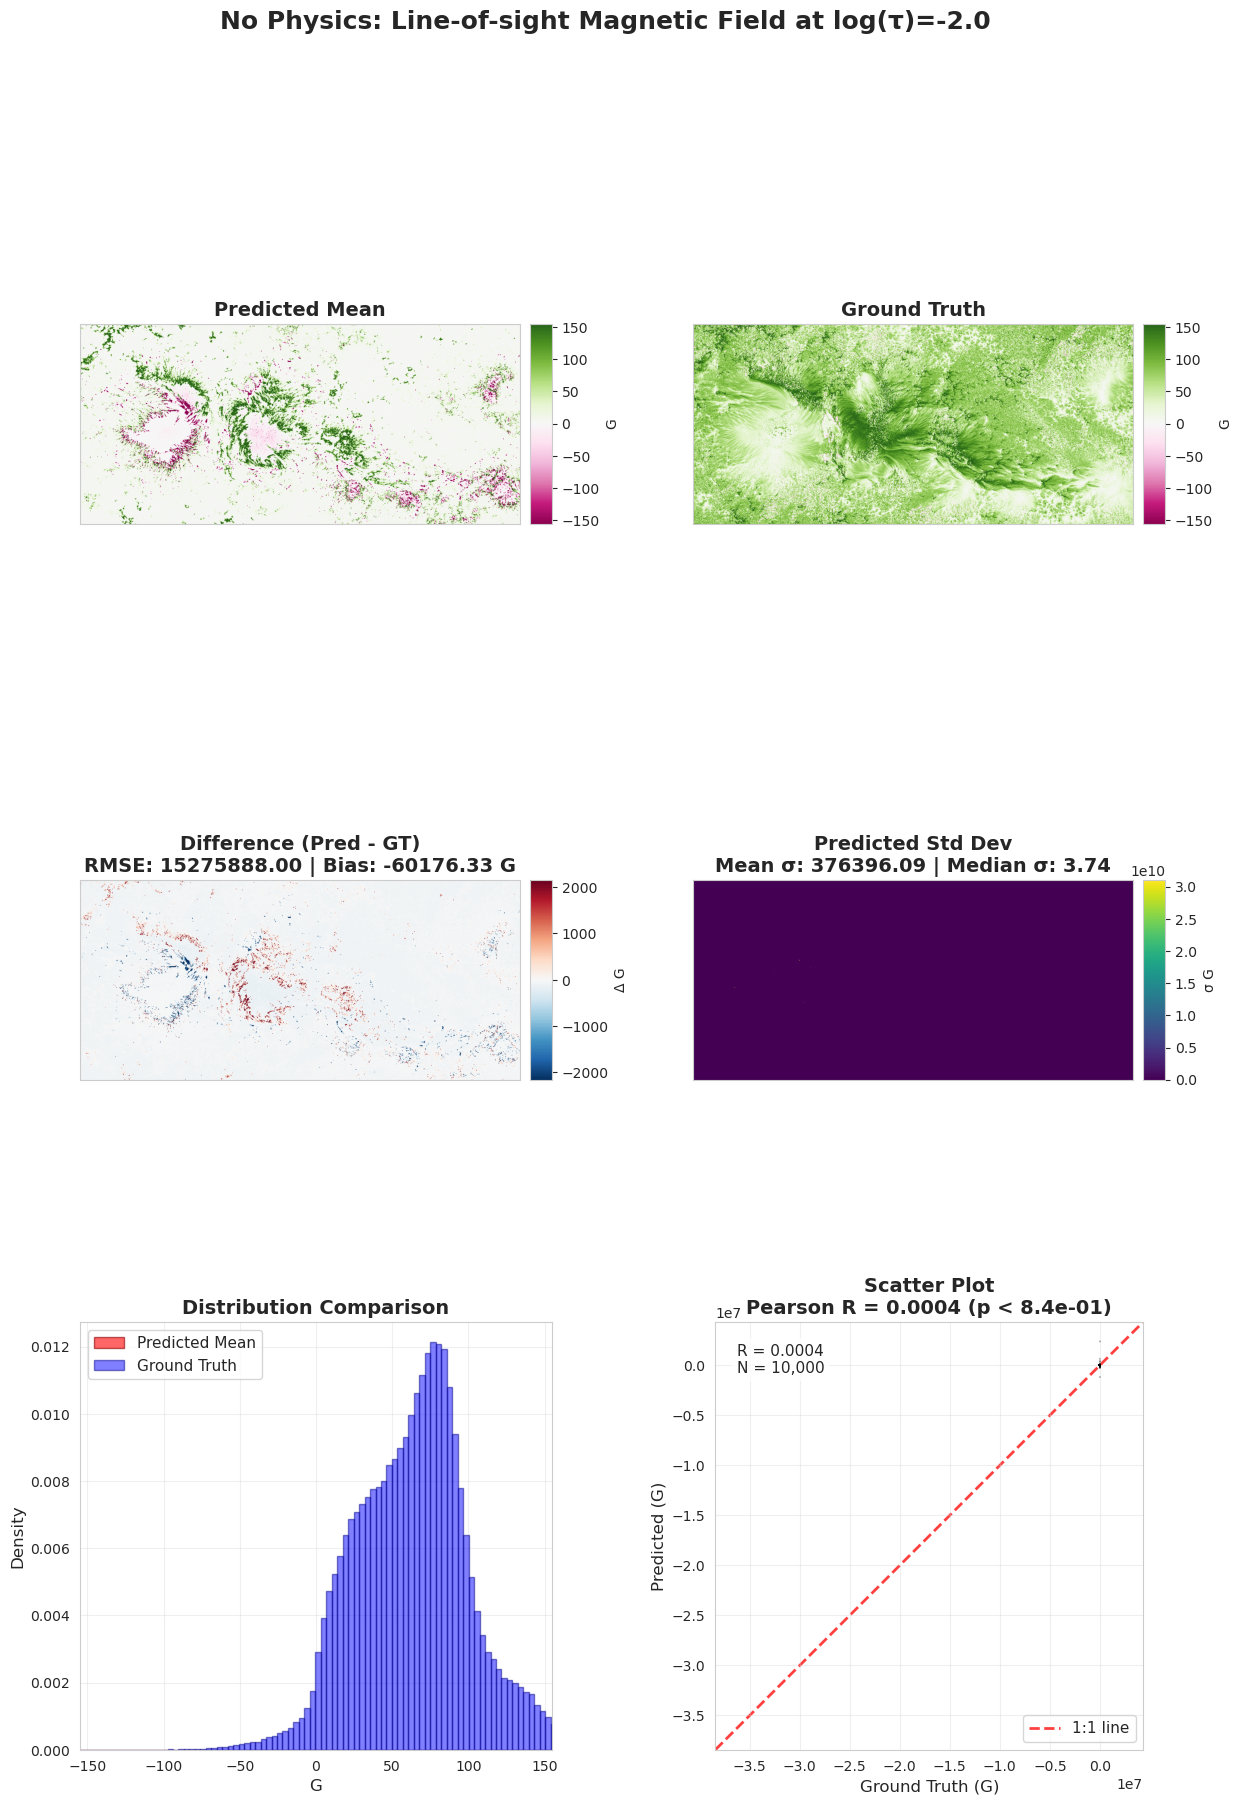


Summary for No Physics: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0004 (p-value: 8.39e-01)
RMSE:        15275888.000 G
Bias:        -60176.332 G
Mean σ:      376396.094 G
Median σ:    3.738 G



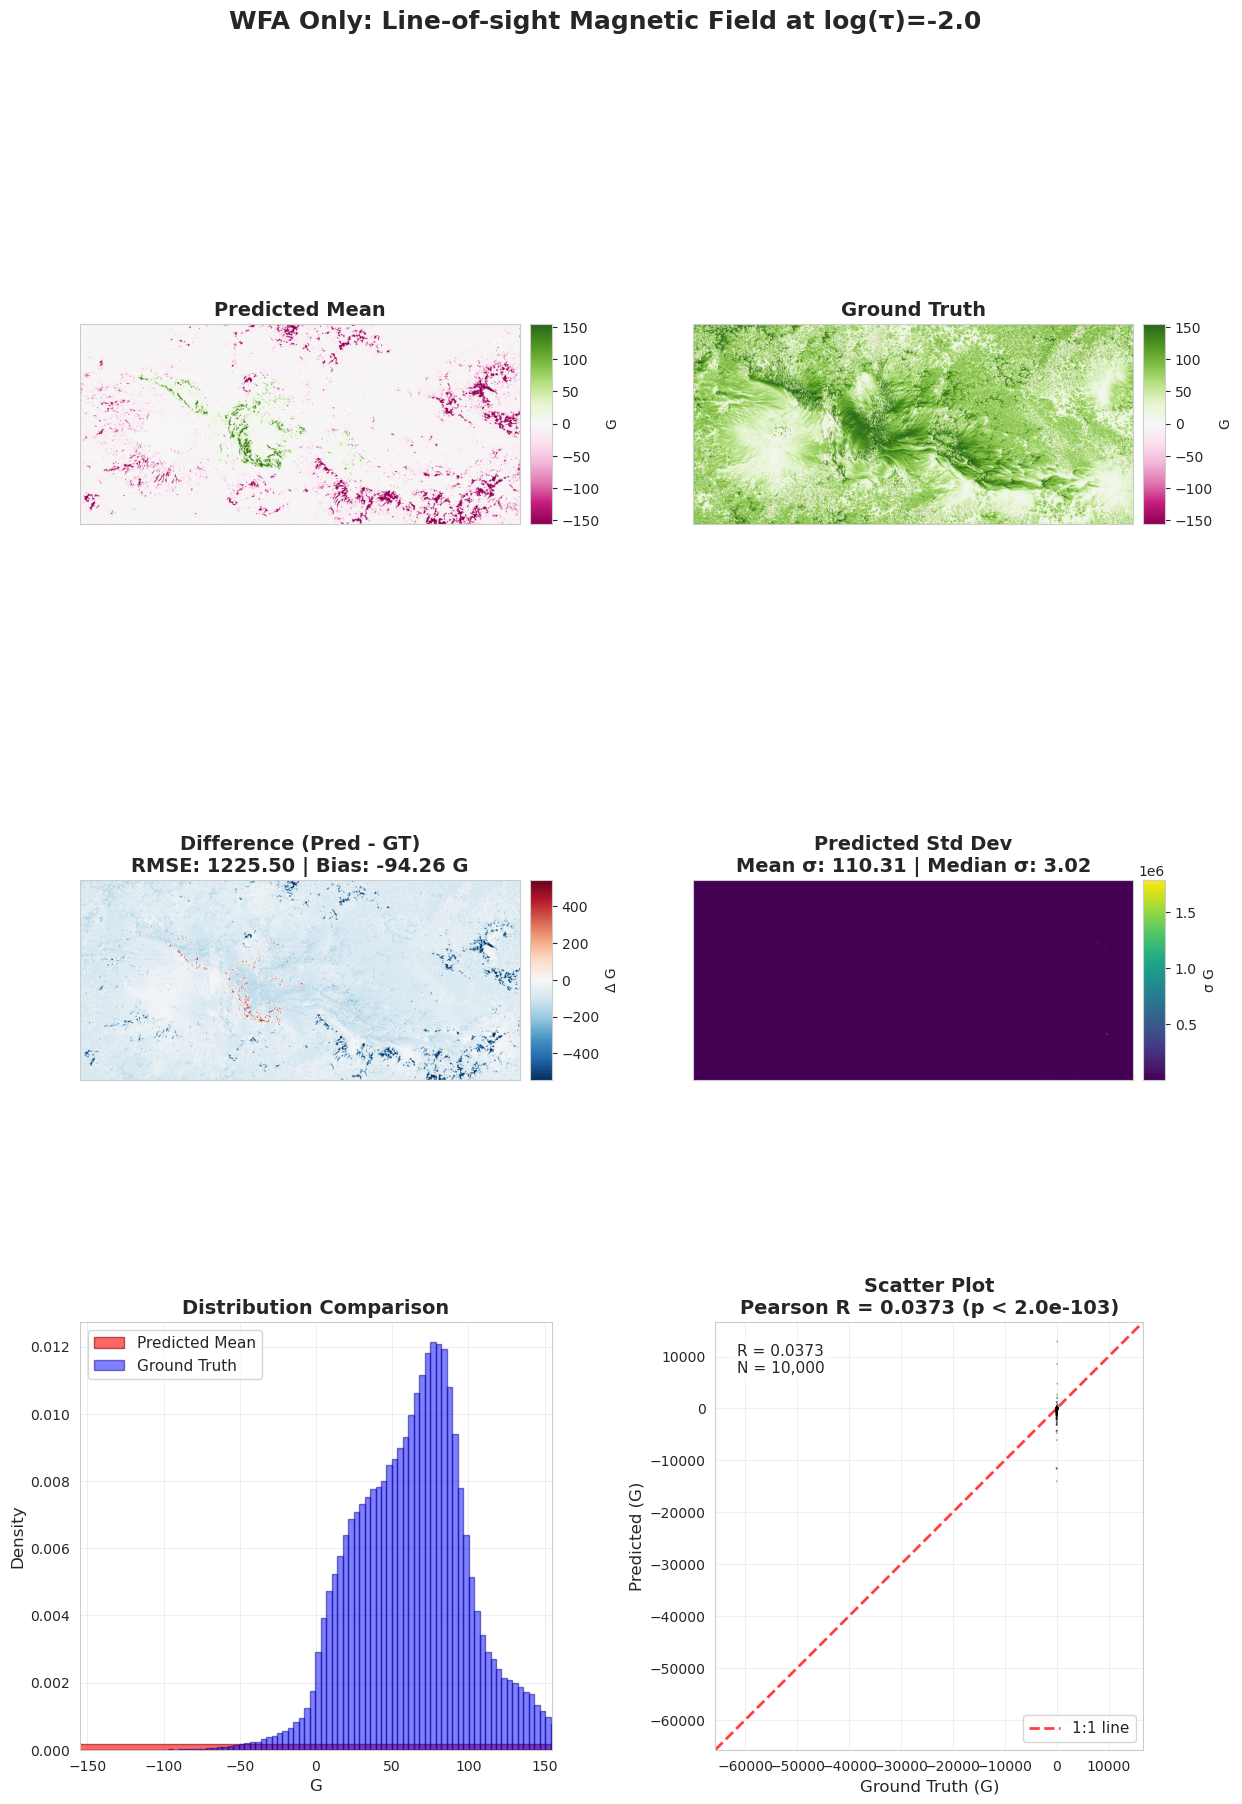


Summary for WFA Only: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0373 (p-value: 1.99e-103)
RMSE:        1225.497 G
Bias:        -94.262 G
Mean σ:      110.309 G
Median σ:    3.021 G



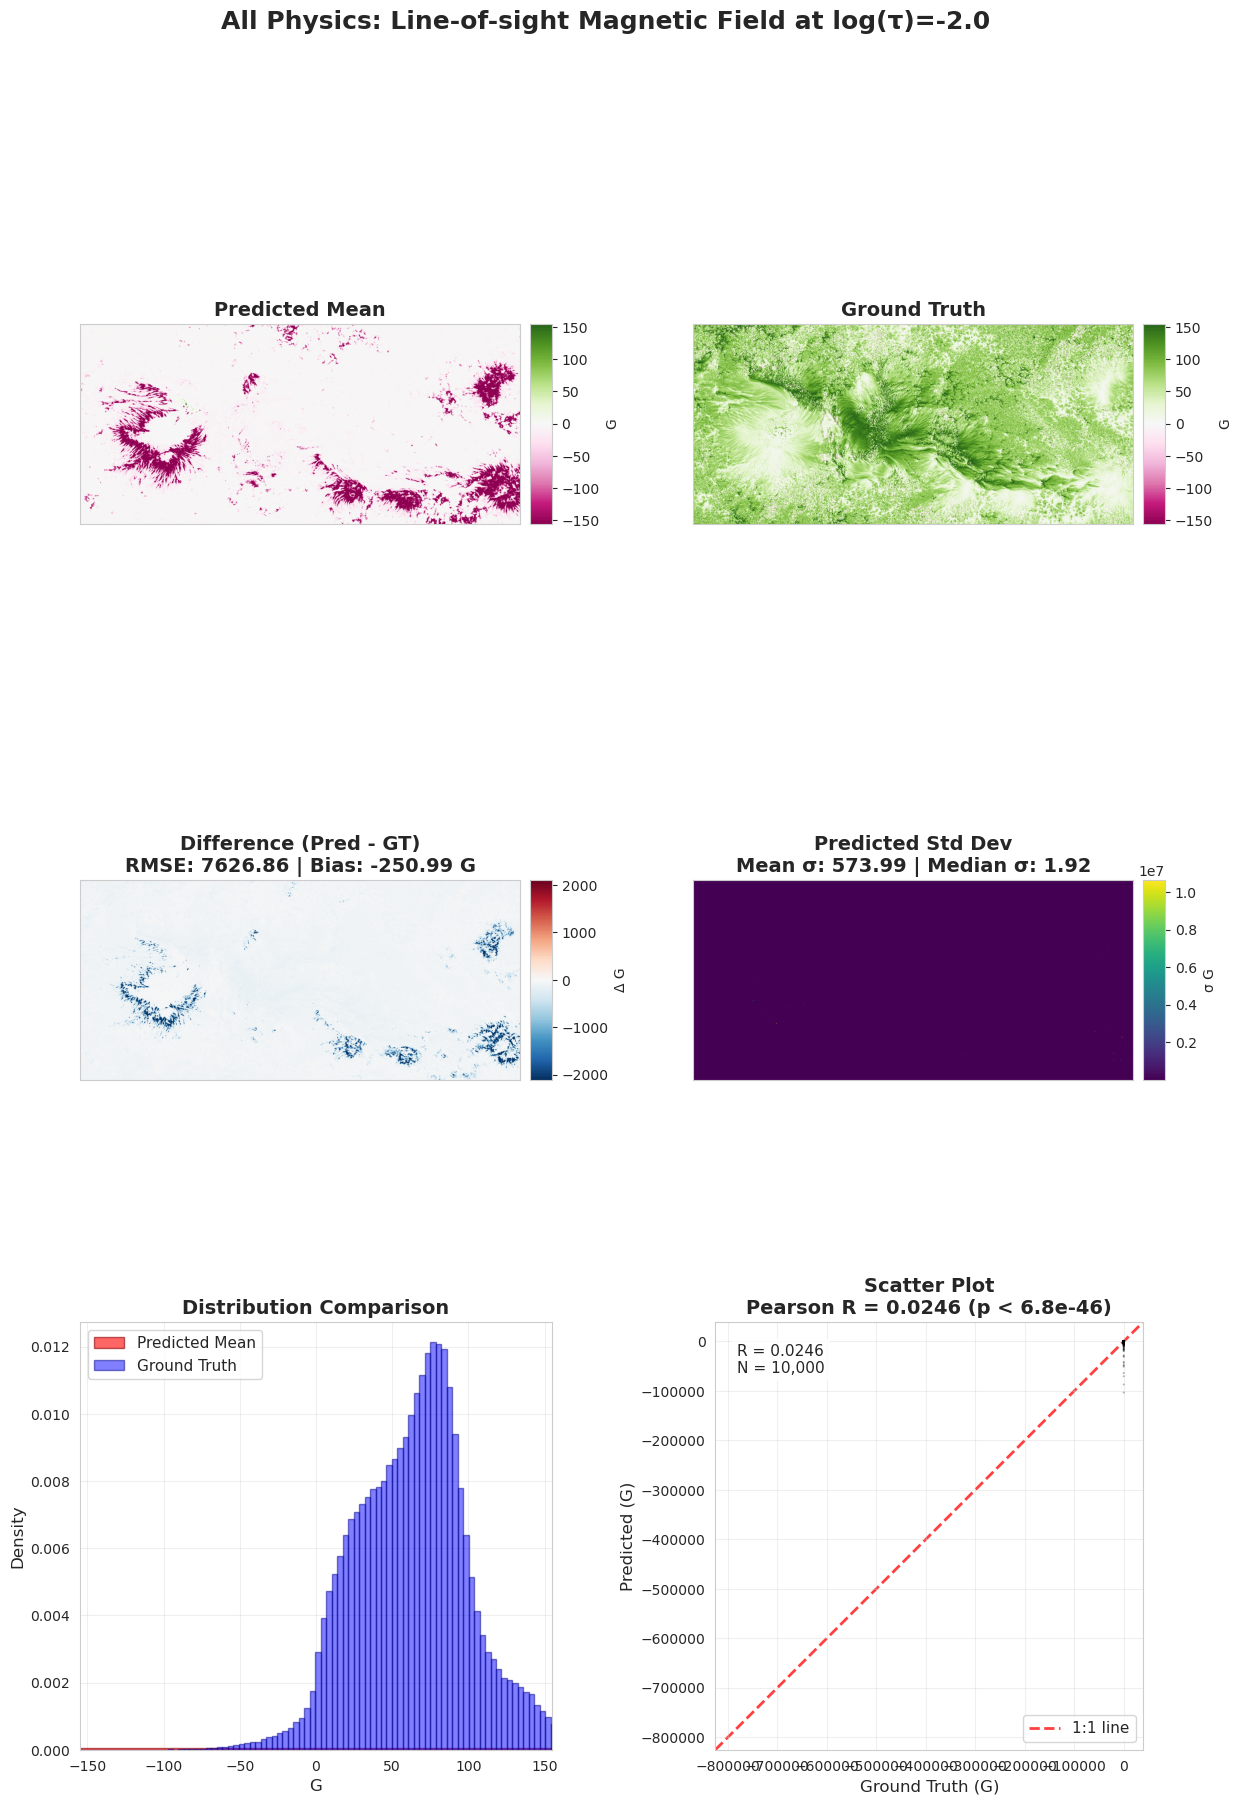


Summary for All Physics: Line-of-sight Magnetic Field at log(τ)=-2.0
Pearson R:   0.0246 (p-value: 6.79e-46)
RMSE:        7626.859 G
Bias:        -250.993 G
Mean σ:      573.989 G
Median σ:    1.919 G



In [15]:
# Choose optical depth and parameter
od_to_plot = -2.0  # log(tau) = 0
mag_to_plot = "Bz"  # Temperature
logtau = np.arange(-2, 0.1, 0.1)

# Plot each model
for model_name, pred_data in all_predictions.items():
    plot_prediction_comparison(
        mean_atm=pred_data['mean'],
        std_atm=pred_data['std'],
        ground_truth=modest.spinor_atm,
        mag_to_plot=mag_to_plot,
        od_to_plot=od_to_plot,
        logtau=logtau,
        model_label=pred_data['label'],
        figsize=(14, 20)
    )

## 8. Multi-Model Comparison

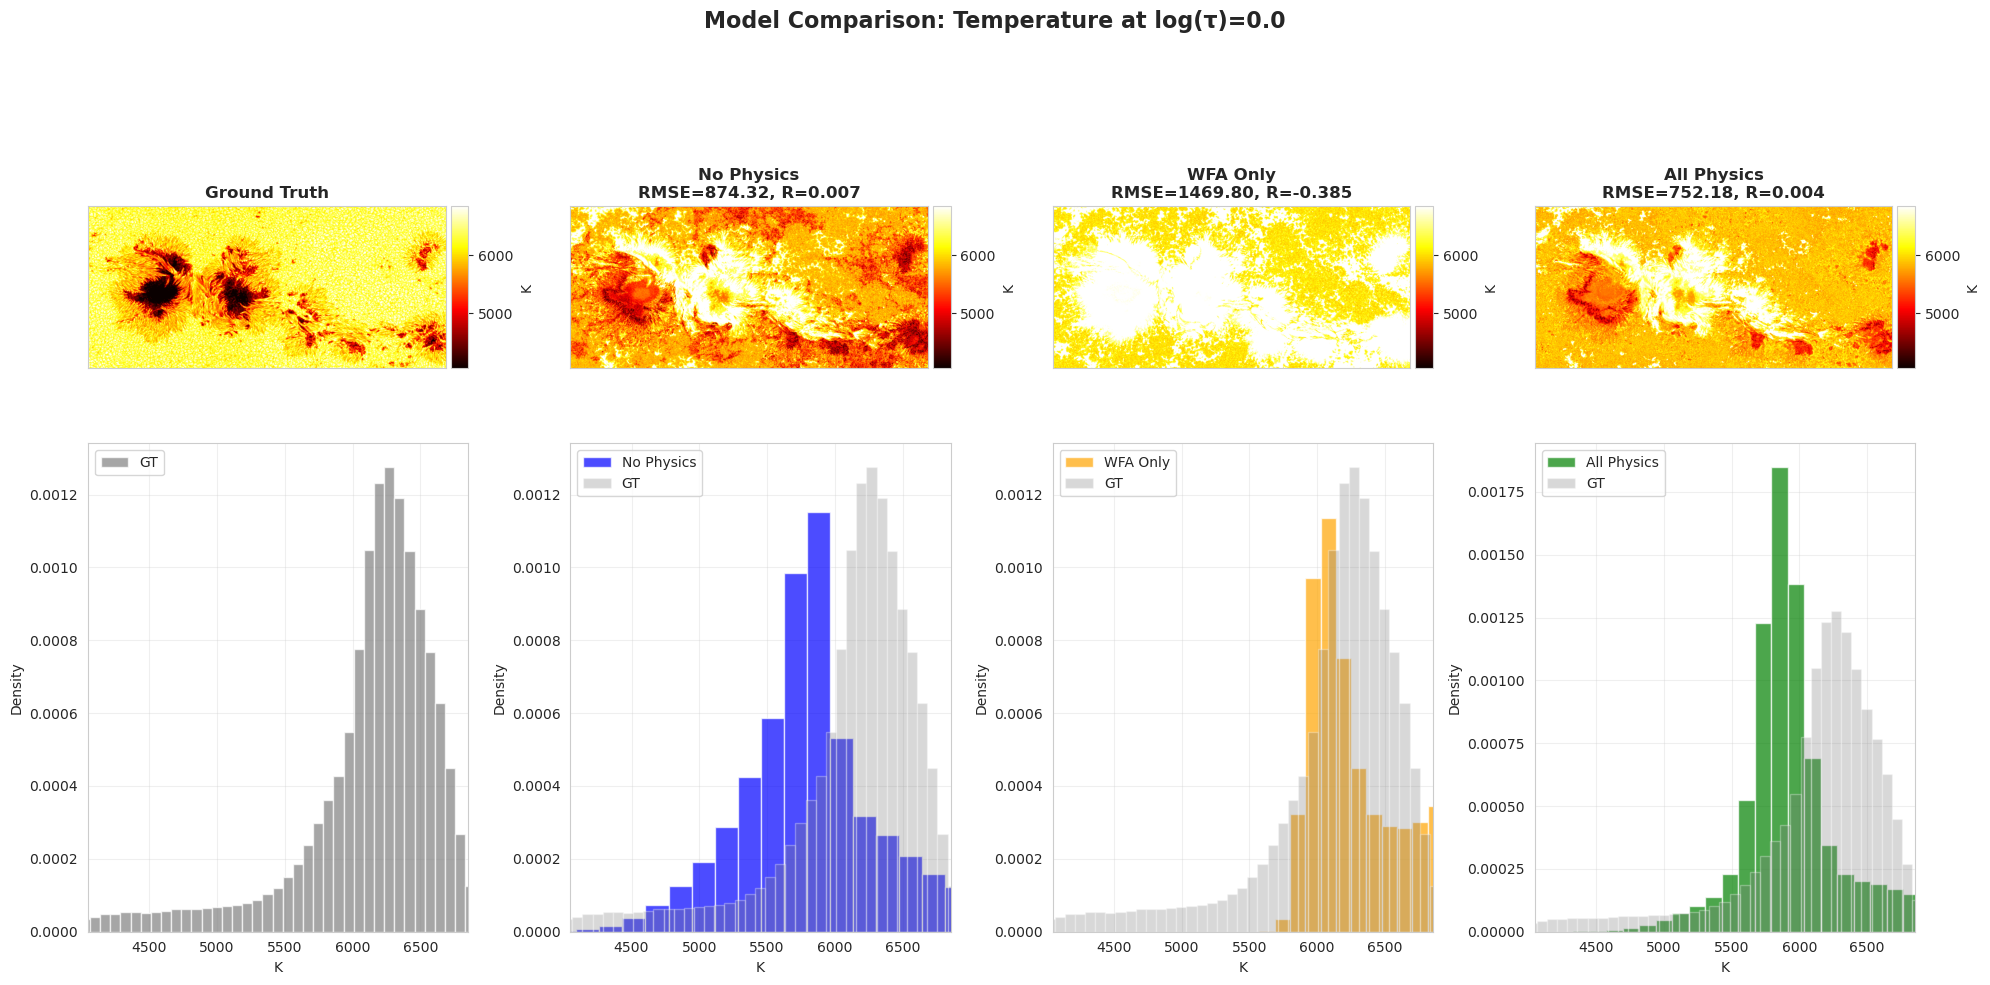

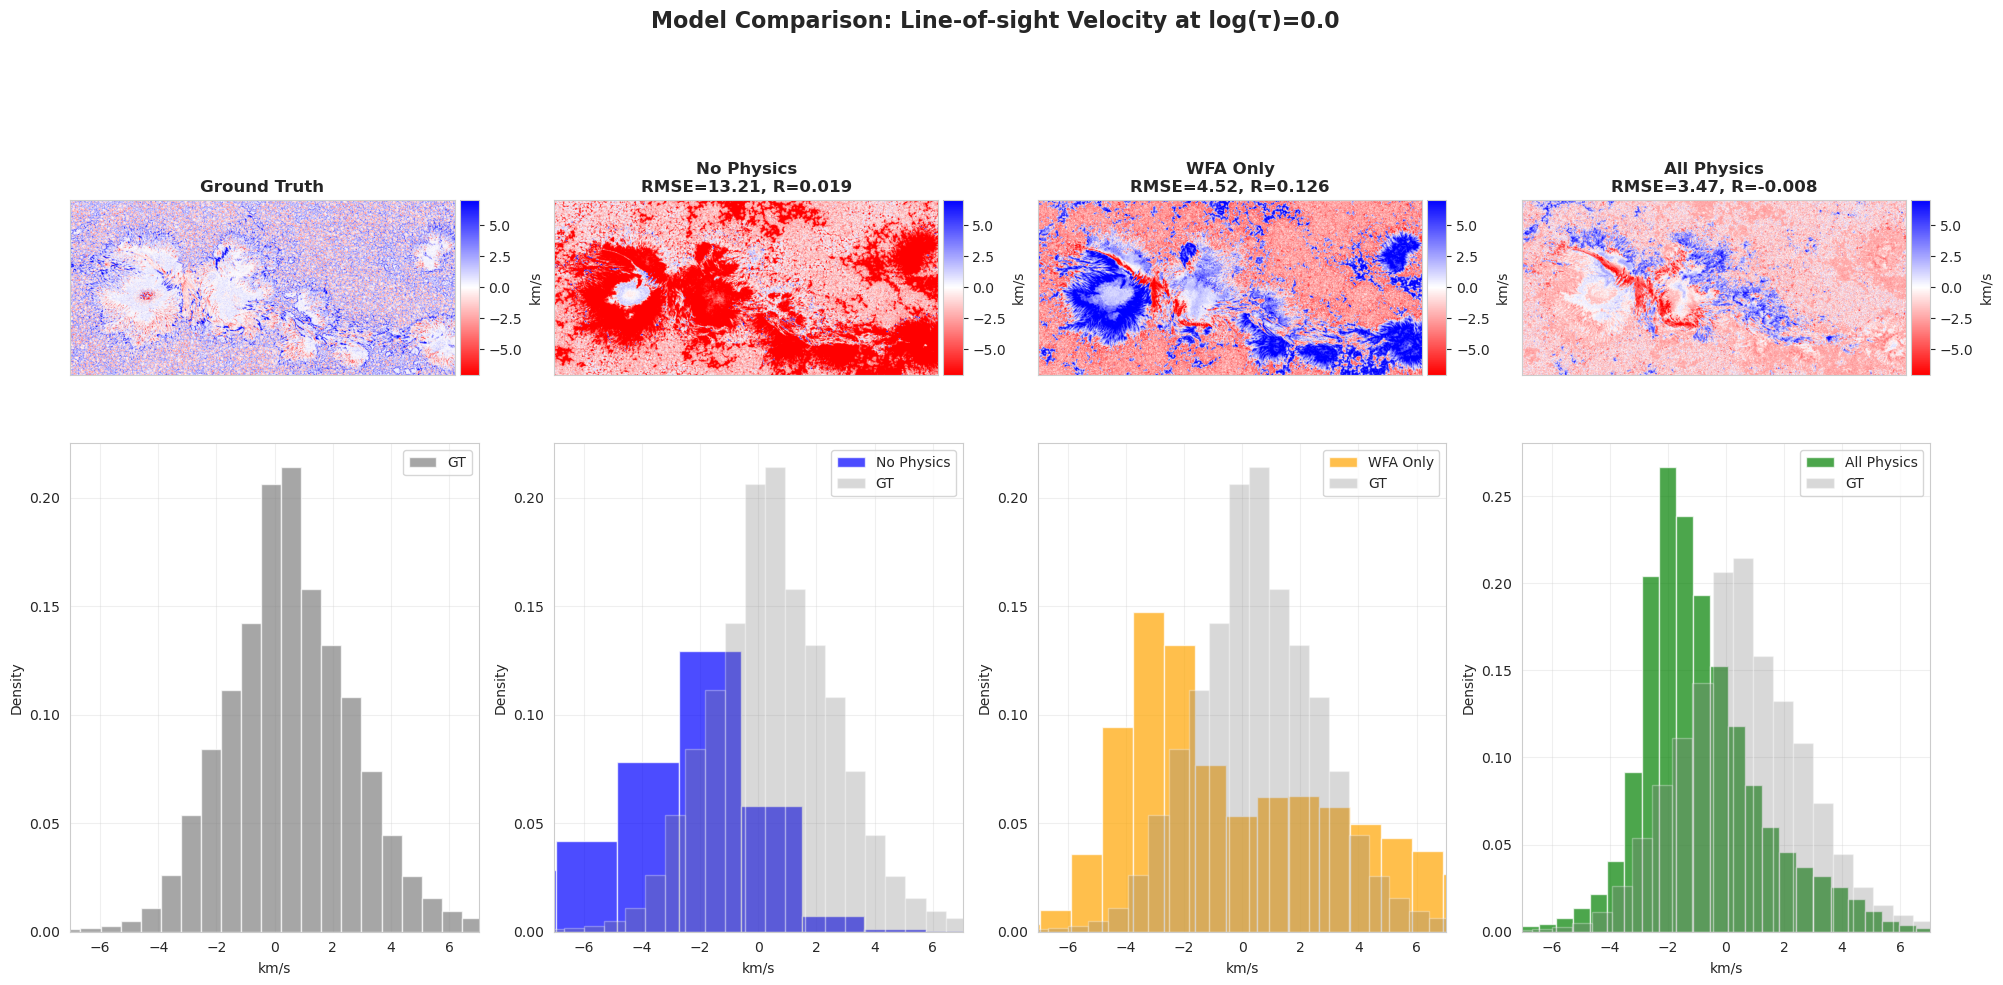

/tmp/ipykernel_1425124/3679225112.py:237: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(difference**2))
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


ValueError: supplied range of [-7.217726913478053e+26, inf] is not finite

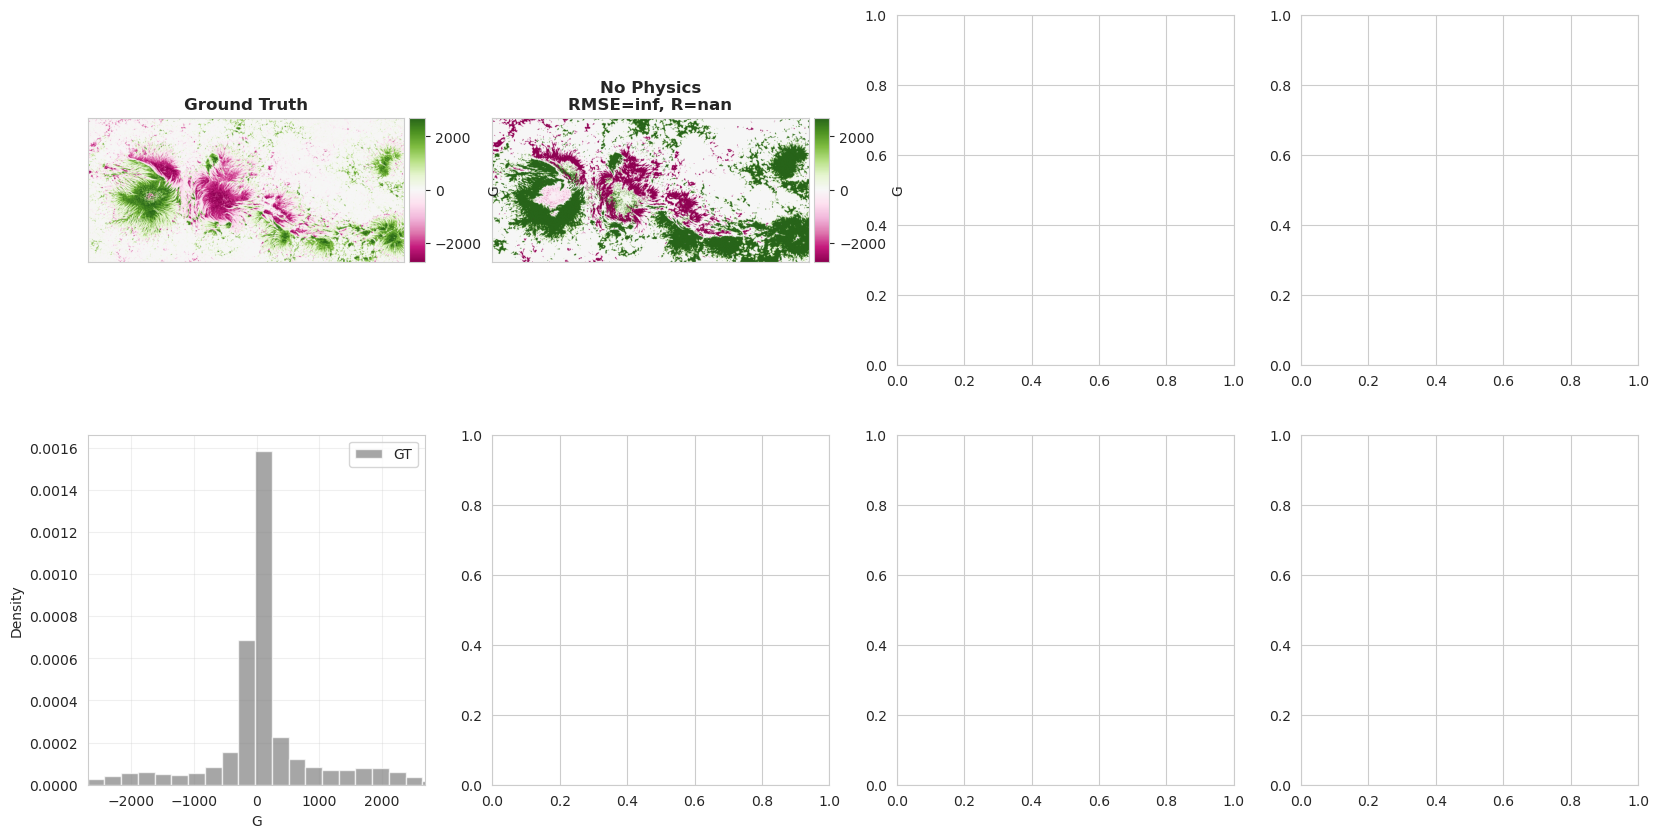

In [12]:
# Compare all models side-by-side
for param in ['T', 'Vz', 'Bz']:
    compare_models_at_optical_depth(
        all_predictions=all_predictions,
        ground_truth=modest.spinor_atm,
        mag_to_plot=param,
        od_to_plot=0.0,
        logtau=logtau,
        figsize=(20, 10)
    )

## 9. Metrics Across Optical Depths

In [61]:
def plot_mean_vs_optical_depth(
    mean_atm, 
    std_atm, 
    logtau=None, 
    figsize=(18, 6),
    log_scale=None,
    ylims=None,
    ground_truth=None
):
    """
    Plot mean atmospheric parameters with uncertainties across optical depths.
    
    Parameters
    ----------
    mean_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing mean predictions (H, W, n_heights)
    std_atm : dict
        Dictionary with keys ['T', 'Vz', 'Bz'] containing standard deviations (H, W, n_heights)
    logtau : np.ndarray, optional
        Array of log(tau) values for x-axis
    figsize : tuple
        Figure size
    log_scale : dict, optional
        Dictionary specifying log scale for each parameter's y-axis.
        Example: {'T': False, 'Vz': False, 'Bz': True}
        If None, all axes use linear scale.
    ylims : dict, optional
        Dictionary specifying y-axis limits for each parameter.
        Example: {'T': (4000, 8000), 'Vz': (-2, 2), 'Bz': (0, 1000)}
        Use None for auto limits, or (ymin, ymax) tuple for custom limits.
        If None, all axes use automatic limits.
    ground_truth : dict, optional
        Dictionary with keys ['T', 'Vlos', 'Blos'] containing ground truth SPINOR atmosphere.
        If provided, will plot ground truth means at available optical depths (-2.0, -0.8, 0.0).
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    # Default: no log scale
    if log_scale is None:
        log_scale = {'T': False, 'Vz': False, 'Bz': False}
    
    # Default: auto limits
    if ylims is None:
        ylims = {'T': None, 'Vz': None, 'Bz': None}
    
    # Configuration
    params = ['T', 'Vz', 'Bz']
    titles = {
        'T': 'Temperature',
        'Vz': 'Line-of-sight Velocity',
        'Bz': 'Line-of-sight Magnetic Field'
    }
    units = {'T': 'K', 'Vz': 'km/s', 'Bz': 'G'}
    colors = {'T': 'red', 'Vz': 'blue', 'Bz': 'green'}
    gt_key_mapping = {'T': 'T', 'Vz': 'Vlos', 'Bz': 'Blos'}
    
    # Available optical depths in MODEST ground truth
    gt_optical_depths = [-2.0, -0.8, 0.0]
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for idx, param in enumerate(params):
        # Compute spatial mean and std across all pixels for each optical depth
        mean_spatial = np.mean(mean_atm[param], axis=(0, 1))  # Shape: (n_heights,)
        std_spatial = np.mean(std_atm[param], axis=(0, 1))    # Mean uncertainty
        
        # Plot mean with shaded uncertainty region
        axes[idx].plot(logtau, mean_spatial, color=colors[param], 
                      linewidth=2, label='Model Mean', zorder=3)
        axes[idx].fill_between(
            logtau,
            mean_spatial - std_spatial,
            mean_spatial + std_spatial,
            color=colors[param],
            alpha=0.3,
            label='±1σ uncertainty',
            zorder=2
        )
        
        # Add ground truth if provided
        if ground_truth is not None:
            gt_means = []
            gt_od_values = []
            
            for od_val in gt_optical_depths:
                if od_val in ground_truth[gt_key_mapping[param]]:
                    # Get ground truth data for this optical depth
                    gt_data = ground_truth[gt_key_mapping[param]][od_val]
                    # Compute spatial mean
                    gt_mean = np.mean(gt_data)
                    gt_means.append(gt_mean)
                    gt_od_values.append(od_val)
            
            # Plot ground truth points
            if gt_means:
                axes[idx].scatter(gt_od_values, gt_means, 
                                color='black', s=100, marker='o',
                                edgecolors='white', linewidths=2,
                                label='Ground Truth (SPINOR)', zorder=4)
                
                # Add annotations for each GT point
                for od_val, gt_mean in zip(gt_od_values, gt_means):
                    # Find closest logtau index
                    od_idx_closest = np.argmin(np.abs(logtau - od_val))
                    pred_mean_at_od = mean_spatial[od_idx_closest]
                    pred_std_at_od = std_spatial[od_idx_closest]
                    
                    # Check if GT is within ±1σ
                    within_uncertainty = (gt_mean >= pred_mean_at_od - pred_std_at_od and 
                                        gt_mean <= pred_mean_at_od + pred_std_at_od)
                    
                    # Add annotation
                    marker = '✓' if within_uncertainty else '✗'
                    color_marker = 'green' if within_uncertainty else 'red'
                    axes[idx].annotate(marker, 
                                     xy=(od_val, gt_mean),
                                     xytext=(10, 10), textcoords='offset points',
                                     fontsize=14, fontweight='bold',
                                     color=color_marker,
                                     bbox=dict(boxstyle='round,pad=0.3', 
                                             facecolor='white', 
                                             edgecolor=color_marker, 
                                             alpha=0.8))
        
        # Apply log scale if requested
        if log_scale.get(param, False):
            axes[idx].set_yscale('log')
        
        # Apply custom y-limits if specified
        if ylims.get(param) is not None:
            axes[idx].set_ylim(ylims[param])
        
        # Formatting
        axes[idx].set_xlabel('log(τ)', fontsize=12)
        ylabel = f'{titles[param]} ({units[param]})'
        if log_scale.get(param, False):
            ylabel += ' [log scale]'
        axes[idx].set_ylabel(ylabel, fontsize=12)
        axes[idx].set_title(titles[param], fontsize=14, fontweight='bold')
        axes[idx].grid(alpha=0.3)
        axes[idx].legend(loc='best', fontsize=10)
        axes[idx].invert_xaxis()  # Optical depth convention
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics if ground truth provided
    if ground_truth is not None:
        print("\n" + "="*70)
        print("Ground Truth Comparison at Available Optical Depths")
        print("="*70)
        
        for param in params:
            print(f"\n{titles[param]} ({units[param]}):")
            print("-" * 70)
            
            for od_val in gt_optical_depths:
                if od_val in ground_truth[gt_key_mapping[param]]:
                    # Ground truth data (spatial distribution)
                    gt_data = ground_truth[gt_key_mapping[param]][od_val]
                    gt_mean = np.mean(gt_data)
                    gt_std = np.std(gt_data)
                    
                    # Prediction at this optical depth (spatial distribution)
                    od_idx = np.argmin(np.abs(logtau - od_val))
                    pred_data = mean_atm[param][:, :, od_idx]
                    pred_mean_spatial = np.mean(pred_data)
                    pred_std_spatial = np.mean(std_atm[param][:, :, od_idx])
                    
                    # Flatten arrays for pixel-wise comparison
                    gt_flat = gt_data.flatten()
                    pred_flat = pred_data.flatten()
                    
                    # Remove NaNs if any
                    valid_mask = ~np.isnan(gt_flat) & ~np.isnan(pred_flat)
                    gt_flat_valid = gt_flat[valid_mask]
                    pred_flat_valid = pred_flat[valid_mask]
                    
                    # Calculate metrics
                    diff = pred_mean_spatial - gt_mean
                    relative_diff = (diff / gt_mean) * 100 if gt_mean != 0 else 0
                    
                    # RMSE (pixel-wise)
                    rmse = np.sqrt(np.mean((pred_flat_valid - gt_flat_valid)**2))
                    
                    # RRMSE (Relative RMSE)
                    if np.abs(gt_mean) > 1e-10:
                        rrmse = rmse / np.abs(gt_mean)
                    else:
                        rrmse = np.nan
                    
                    # Pearson correlation (pixel-wise)
                    if len(gt_flat_valid) > 1:
                        corr, p_value = pearsonr(gt_flat_valid, pred_flat_valid)
                    else:
                        corr, p_value = np.nan, np.nan
                    
                    # Check if within uncertainty
                    within_uncertainty = abs(diff) <= pred_std_spatial
                    status = "✓ WITHIN" if within_uncertainty else "✗ OUTSIDE"
                    
                    print(f"  log(τ) = {od_val:5.1f}:")
                    print(f"    Ground Truth:  {gt_mean:10.2f} ± {gt_std:8.2f} {units[param]}")
                    print(f"    Model Pred:    {pred_mean_spatial:10.2f} ± {pred_std_spatial:8.2f} {units[param]}")
                    print(f"    Difference:    {diff:10.2f} ({relative_diff:+.1f}%)")
                    print(f"    RMSE:          {rmse:10.2f} {units[param]}")
                    if not np.isnan(rrmse):
                        print(f"    RRMSE:         {rrmse:10.4f} ({rrmse*100:.2f}%)")
                    else:
                        print(f"    RRMSE:         N/A (GT mean too small)")
                    if not np.isnan(corr):
                        print(f"    Correlation:   {corr:10.4f} (p={p_value:.2e})")
                    else:
                        print(f"    Correlation:   N/A")
                    print(f"    Status:        {status} ±1σ uncertainty")
        
        print("\n" + "="*70)


Model: No Physics


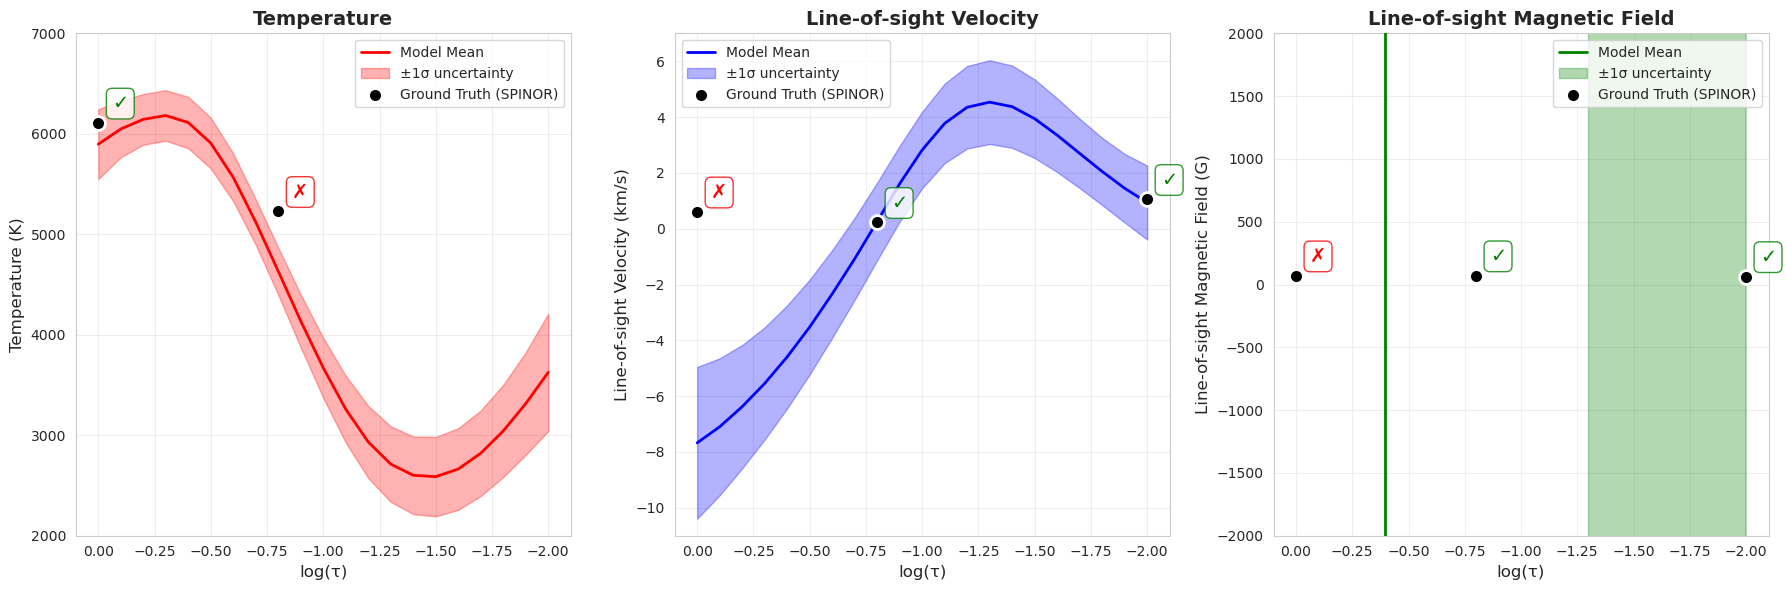


Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       3626.18 ±   584.54 K
    Difference:       2810.68 (+344.7%)
    RMSE:             4726.11 K
    RRMSE:             5.7954 (579.54%)
    Correlation:      -0.6388 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       4632.18 ±   235.57 K
    Difference:       -595.53 (-11.4%)
    RMSE:             1193.90 K
    RRMSE:             0.2284 (22.84%)
    Correlation:       0.2724 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       5896.94 ±   347.26 K
    Difference:       -210.65 (-3.4%)
    RMSE:              874.32 K
    RRMSE:             0.1432 (14.32%)
    Correlation:       0.0066 (p=1.37e-

/tmp/ipykernel_1425124/3163947128.py:185: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_flat_valid - gt_flat_valid)**2))
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4624: RuntimeWarning: invalid value encountered in subtract
  ym = y - ymean


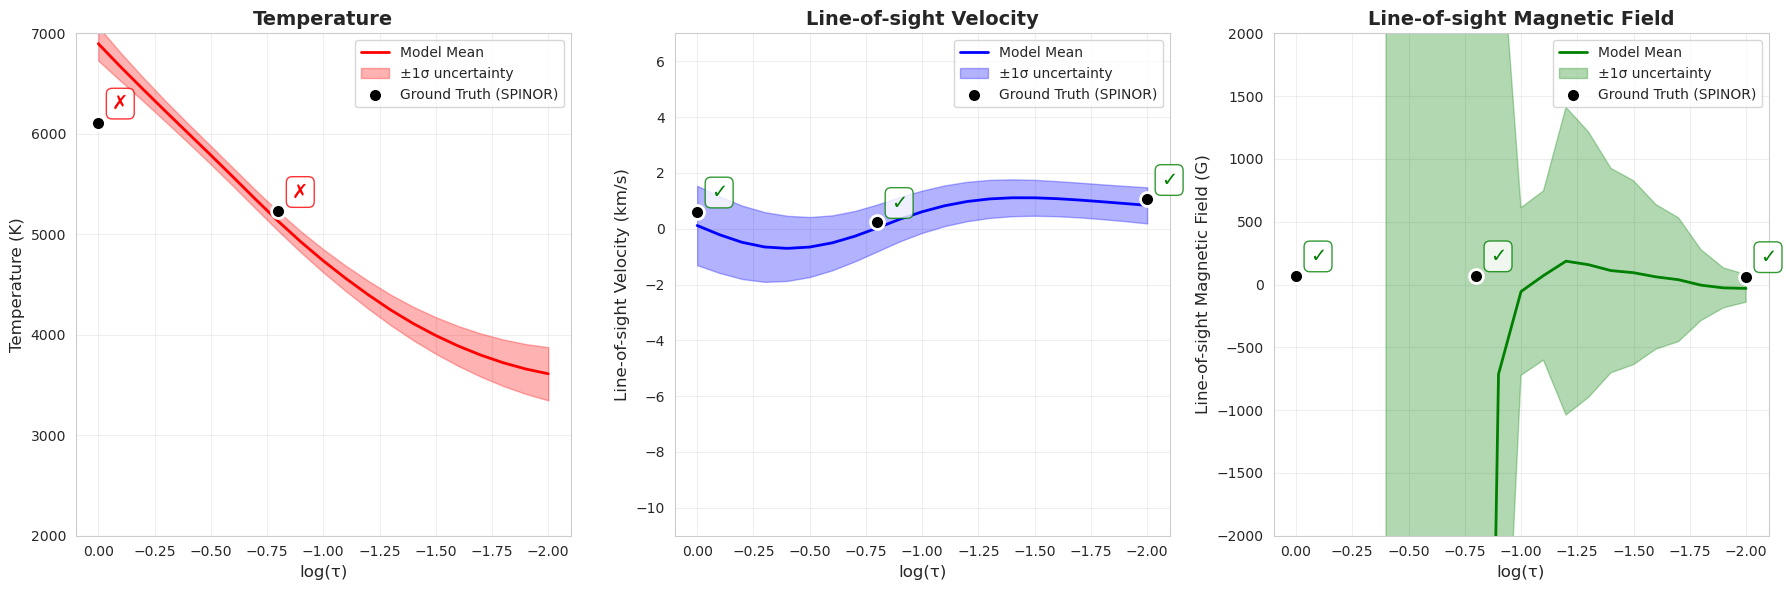


Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       3611.71 ±   264.63 K
    Difference:       2796.22 (+342.9%)
    RMSE:             4027.99 K
    RRMSE:             4.9393 (493.93%)
    Correlation:      -0.7170 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       5129.48 ±    96.59 K
    Difference:        -98.23 (-1.9%)
    RMSE:              567.72 K
    RRMSE:             0.1086 (10.86%)
    Correlation:       0.2106 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       6897.39 ±   169.10 K
    Difference:        789.79 (+12.9%)
    RMSE:             1469.80 K
    RRMSE:             0.2407 (24.07%)
    Correlation:      -0.3846 (p=0.00e+

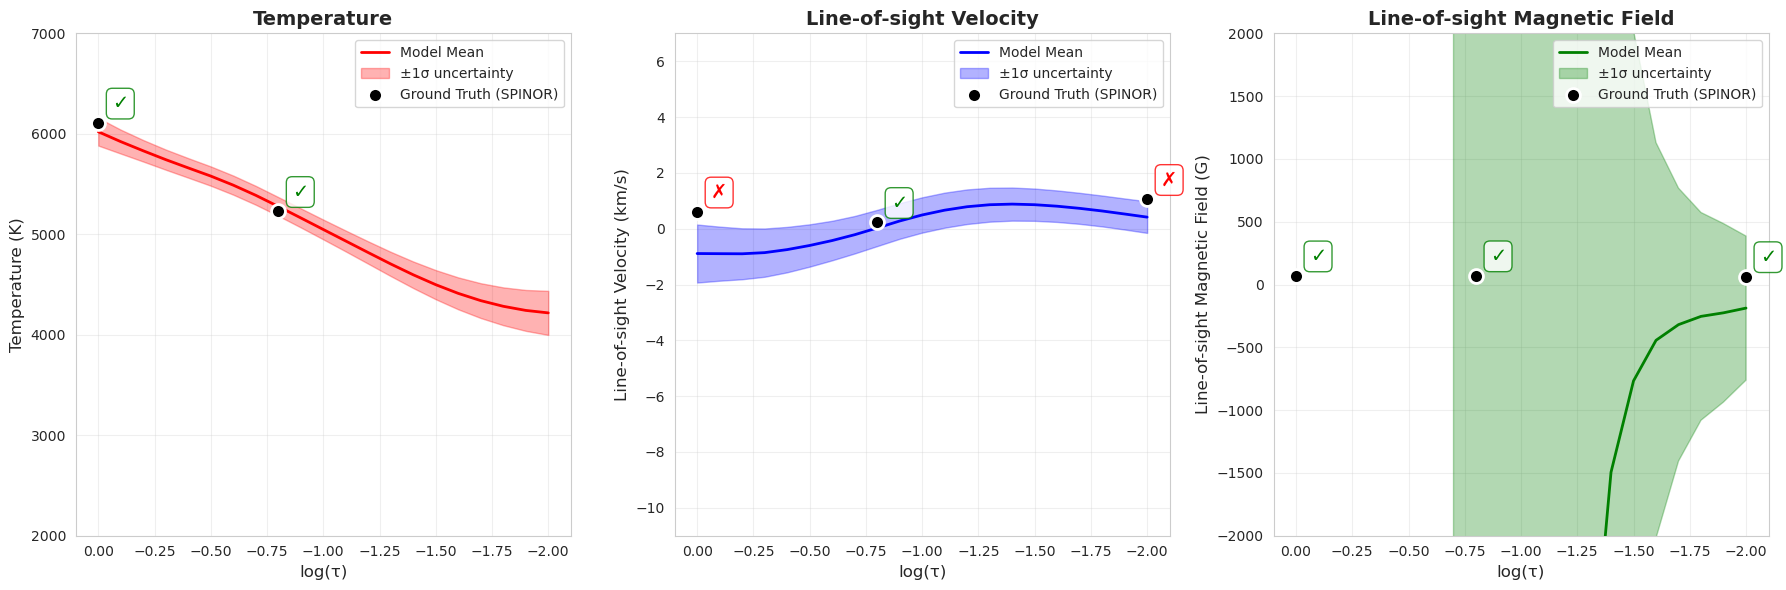


Ground Truth Comparison at Available Optical Depths

Temperature (K):
----------------------------------------------------------------------
  log(τ) =  -2.0:
    Ground Truth:      815.50 ±   739.42 K
    Model Pred:       4217.81 ±   219.35 K
    Difference:       3402.31 (+417.2%)
    RMSE:             4148.62 K
    RRMSE:             5.0872 (508.72%)
    Correlation:      -0.6477 (p=0.00e+00)
    Status:        ✗ OUTSIDE ±1σ uncertainty
  log(τ) =  -0.8:
    Ground Truth:     5227.71 ±   451.50 K
    Model Pred:       5277.05 ±    93.44 K
    Difference:         49.34 (+0.9%)
    RMSE:              468.82 K
    RRMSE:             0.0897 (8.97%)
    Correlation:       0.3640 (p=0.00e+00)
    Status:        ✓ WITHIN ±1σ uncertainty
  log(τ) =   0.0:
    Ground Truth:     6107.60 ±   559.61 K
    Model Pred:       6020.41 ±   137.55 K
    Difference:        -87.19 (-1.4%)
    RMSE:              752.18 K
    RRMSE:             0.1232 (12.32%)
    Correlation:       0.0036 (p=3.58e-02)

In [62]:
# Example 3: Compare all models with ground truth
for model_name, pred_data in all_predictions.items():
    print(f"\n{'='*80}")
    print(f"Model: {pred_data['label']}")
    print(f"{'='*80}")
    
    plot_mean_vs_optical_depth(
        mean_atm=pred_data['mean'],
        std_atm=pred_data['std'],
        logtau=logtau,
        figsize=(18, 6),
        log_scale={'T': False, 'Vz': False, 'Bz': False},
        ylims={'T': (2000, 7000), 'Vz': (-11, 7), 'Bz': (-2000, 2000)},
        ground_truth=modest.spinor_atm
    )

## 10. Seaborn-based Statistical Analysis

In [94]:
def plot_jointplot_comparison(
    all_predictions: Dict,
    ground_truth: dict,
    mag_to_plot: str = "Bz",
    od_val: float = 0.0,
    logtau: np.ndarray = None,
    n_samples: int = 10000,
    kind: str = 'scatter'
):
    """
    Create jointplots comparing predictions vs ground truth for all models.
    
    Parameters
    ----------
    all_predictions : Dict
        Dictionary of model predictions
    ground_truth : dict
        Ground truth SPINOR atmosphere
    mag_to_plot : str
        Parameter to plot: 'T', 'Vz', or 'Bz'
    od_val : float
        Optical depth value to analyze
    logtau : np.ndarray, optional
        Optical depth grid
    n_samples : int
        Number of samples to plot (for performance)
    kind : str
        Type of plot: 'scatter', 'hex', 'kde', or 'reg'
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    # Configuration
    title_map = {"T": "Temperature", "Vz": "Line-of-sight Velocity", "Bz": "Line-of-sight Magnetic Field"}
    units_map = {"T": "K", "Vz": "km/s", "Bz": "G"}
    gt_key_mapping = {"T": "T", "Vz": "Vlos", "Bz": "Blos"}
    
    od_idx = np.argmin(np.abs(logtau - od_val))
    gt_data = ground_truth[gt_key_mapping[mag_to_plot]][od_val]
    
    # Create jointplots for each model (each gets its own figure)
    for idx, (model_name, pred_data) in enumerate(all_predictions.items()):
        pred_mean = pred_data['mean'][mag_to_plot][:, :, od_idx]
        
        # Flatten and sample
        gt_flat = gt_data.flatten()
        pred_flat = pred_mean.flatten()
        
        # Remove NaNs
        valid = ~np.isnan(gt_flat) & ~np.isnan(pred_flat)
        gt_valid = gt_flat[valid]
        pred_valid = pred_flat[valid]
        
        # Subsample for performance
        if len(gt_valid) > n_samples:
            indices = np.random.choice(len(gt_valid), n_samples, replace=False)
            gt_valid = gt_valid[indices]
            pred_valid = pred_valid[indices]
        
        # Create DataFrame for seaborn
        df_plot = pd.DataFrame({
            'Ground Truth': gt_valid,
            'Prediction': pred_valid
        })
        
        # Compute metrics
        corr, p_value = pearsonr(gt_valid, pred_valid)
        rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))
        bias = np.mean(pred_valid - gt_valid)
        
        # Create jointplot using JointGrid (creates its own figure)
        g = sns.JointGrid(data=df_plot, x='Ground Truth', y='Prediction', 
                         height=6, ratio=5, space=0.2)
        
        # Main plot
        if kind == 'scatter':
            g.plot_joint(sns.scatterplot, alpha=0.3, s=10, color=pred_data['color'])
        elif kind == 'hex':
            g.plot_joint(plt.hexbin, gridsize=30, cmap='Blues', mincnt=1)
        elif kind == 'kde':
            g.plot_joint(sns.kdeplot, cmap='Blues', fill=True, levels=10)
        elif kind == 'reg':
            g.plot_joint(sns.regplot, scatter_kws={'alpha': 0.3, 's': 10}, 
                        color=pred_data['color'])
        
        # Marginal histograms
        g.plot_marginals(sns.histplot, kde=True, color=pred_data['color'], alpha=0.6, bins=30)
        
        # Add 1:1 line
        lims = [min(g.ax_joint.get_xlim()[0], g.ax_joint.get_ylim()[0]),
                max(g.ax_joint.get_xlim()[1], g.ax_joint.get_ylim()[1])]
        g.ax_joint.plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
        g.ax_joint.set_xlim(lims)
        g.ax_joint.set_ylim(lims)
        
        # Labels
        g.set_axis_labels(f'Ground Truth ({units_map[mag_to_plot]})', 
                         f'Prediction ({units_map[mag_to_plot]})',
                         fontsize=12)
        
        # Title with metrics
        g.fig.suptitle(f"{pred_data['label']}\n"
                      f"R = {corr:.4f} | RMSE = {rmse:.2f} | Bias = {bias:.2f} {units_map[mag_to_plot]}",
                      fontsize=12, fontweight='bold', y=1.02)
        
        # Add statistics box
        stats_text = (f"N = {len(gt_valid):,}\n"
                     f"R = {corr:.4f}\n"
                     f"p < {p_value:.1e}\n"
                     f"RMSE = {rmse:.2f}\n"
                     f"Bias = {bias:.2f}")
        
        g.ax_joint.text(0.05, 0.95, stats_text,
                       transform=g.ax_joint.transAxes,
                       fontsize=10, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        g.ax_joint.legend(loc='lower right', fontsize=10)
        g.ax_joint.grid(alpha=0.3)
        
        plt.show()
        
        # Print summary
        print(f"\n{pred_data['label']} - {title_map[mag_to_plot]} at log(τ)={od_val:.1f}")
        print(f"  Pearson R:   {corr:.4f} (p={p_value:.2e})")
        print(f"  RMSE:        {rmse:.2f} {units_map[mag_to_plot]}")
        print(f"  Bias:        {bias:.2f} {units_map[mag_to_plot]}")
        print(f"  Samples:     {len(gt_valid):,}")


# Alternative: Combined jointplot with all models overlaid
def plot_combined_jointplot(
    all_predictions: Dict,
    ground_truth: dict,
    mag_to_plot: str = "Bz",
    od_val: float = 0.0,
    logtau: np.ndarray = None,
    n_samples: int = 5000
):
    """
    Create a single jointplot with all models overlaid.
    
    Parameters
    ----------
    all_predictions : Dict
        Dictionary of model predictions
    ground_truth : dict
        Ground truth SPINOR atmosphere
    mag_to_plot : str
        Parameter to plot: 'T', 'Vz', or 'Bz'
    od_val : float
        Optical depth value to analyze
    logtau : np.ndarray, optional
        Optical depth grid
    n_samples : int
        Number of samples per model
    """
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    # Configuration
    title_map = {"T": "Temperature", "Vz": "Line-of-sight Velocity", "Bz": "Line-of-sight Magnetic Field"}
    units_map = {"T": "K", "Vz": "km/s", "Bz": "G"}
    gt_key_mapping = {"T": "T", "Vz": "Vlos", "Bz": "Blos"}
    
    od_idx = np.argmin(np.abs(logtau - od_val))
    gt_data = ground_truth[gt_key_mapping[mag_to_plot]][od_val]
    
    # Prepare combined DataFrame
    all_data = []
    
    for model_name, pred_data in all_predictions.items():
        pred_mean = pred_data['mean'][mag_to_plot][:, :, od_idx]
        
        # Flatten
        gt_flat = gt_data.flatten()
        pred_flat = pred_mean.flatten()
        
        # Remove NaNs
        valid = ~np.isnan(gt_flat) & ~np.isnan(pred_flat)
        gt_valid = gt_flat[valid]
        pred_valid = pred_flat[valid]
        
        # Subsample
        if len(gt_valid) > n_samples:
            indices = np.random.choice(len(gt_valid), n_samples, replace=False)
            gt_valid = gt_valid[indices]
            pred_valid = pred_valid[indices]
        
        # Create DataFrame
        df_model = pd.DataFrame({
            'Ground Truth': gt_valid,
            'Prediction': pred_valid,
            'Model': pred_data['label']
        })
        
        all_data.append(df_model)
    
    # Combine all models
    df_combined = pd.concat(all_data, ignore_index=True)
    
    # Create jointplot
    g = sns.JointGrid(data=df_combined, x='Ground Truth', y='Prediction', 
                     hue='Model', height=8, ratio=5, space=0.2)
    
    # Main scatter plot with different colors per model
    g.plot_joint(sns.scatterplot, alpha=0.4, s=10, 
                palette={pred_data['label']: pred_data['color'] 
                        for pred_data in all_predictions.values()})
    
    # Marginal histograms separated by model
    g.plot_marginals(sns.histplot, kde=True, alpha=0.5,
                    palette={pred_data['label']: pred_data['color'] 
                            for pred_data in all_predictions.values()})
    
    # Add 1:1 line
    lims = [min(g.ax_joint.get_xlim()[0], g.ax_joint.get_ylim()[0]),
            max(g.ax_joint.get_xlim()[1], g.ax_joint.get_ylim()[1])]
    g.ax_joint.plot(lims, lims, 'r--', alpha=0.75, linewidth=2, zorder=0, label='1:1 line')
    g.ax_joint.set_xlim(lims)
    g.ax_joint.set_ylim(lims)
    
    # Labels
    g.set_axis_labels(f'Ground Truth ({units_map[mag_to_plot]})', 
                     f'Prediction ({units_map[mag_to_plot]})',
                     fontsize=13, fontweight='bold')
    
    # Title
    g.fig.suptitle(f"Model Comparison: {title_map[mag_to_plot]} at log(τ)={od_val:.1f}",
                  fontsize=14, fontweight='bold', y=1.02)
    
    g.ax_joint.grid(alpha=0.3)
    g.ax_joint.legend(loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary for each model
    print("\n" + "="*70)
    print(f"Combined Analysis: {title_map[mag_to_plot]} at log(τ)={od_val:.1f}")
    print("="*70)
    
    for model_name, pred_data in all_predictions.items():
        df_model = df_combined[df_combined['Model'] == pred_data['label']]
        corr, p_value = pearsonr(df_model['Ground Truth'], df_model['Prediction'])
        rmse = np.sqrt(np.mean((df_model['Prediction'] - df_model['Ground Truth'])**2))
        bias = np.mean(df_model['Prediction'] - df_model['Ground Truth'])
        
        print(f"\n{pred_data['label']}:")
        print(f"  Pearson R:   {corr:.4f} (p={p_value:.2e})")
        print(f"  RMSE:        {rmse:.2f} {units_map[mag_to_plot]}")
        print(f"  Bias:        {bias:.2f} {units_map[mag_to_plot]}")
        print(f"  Samples:     {len(df_model):,}")
    
    print("\n" + "="*70)


Separate Jointplots: T


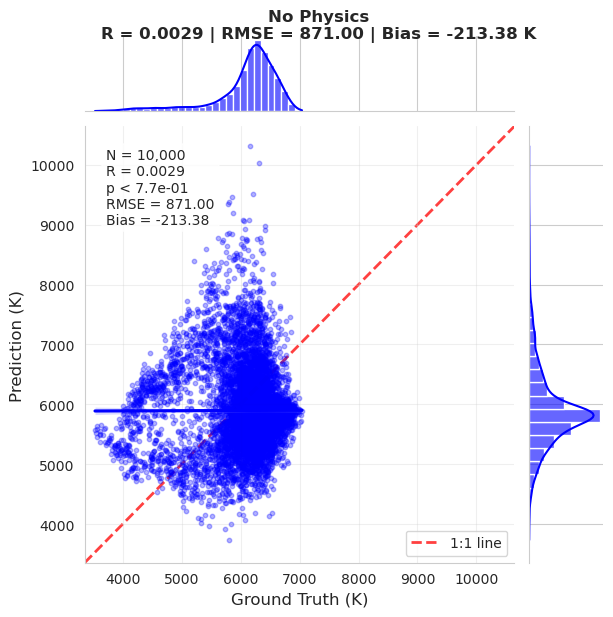


No Physics - Temperature at log(τ)=0.0
  Pearson R:   0.0029 (p=7.71e-01)
  RMSE:        871.00 K
  Bias:        -213.38 K
  Samples:     10,000


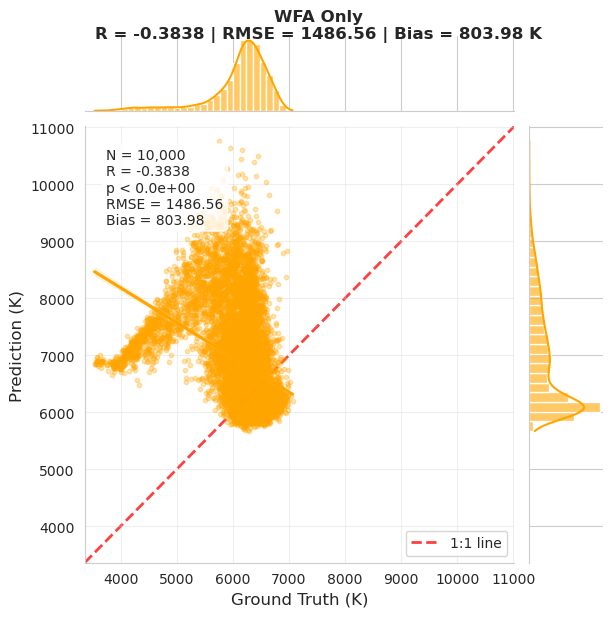


WFA Only - Temperature at log(τ)=0.0
  Pearson R:   -0.3838 (p=0.00e+00)
  RMSE:        1486.56 K
  Bias:        803.98 K
  Samples:     10,000


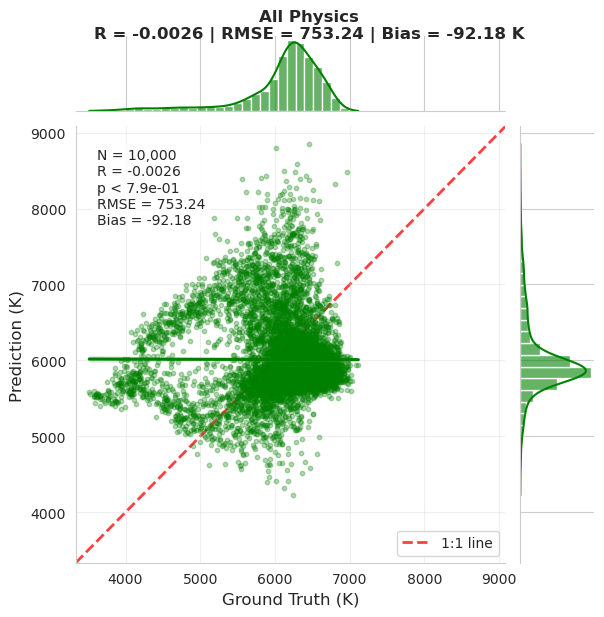


All Physics - Temperature at log(τ)=0.0
  Pearson R:   -0.0026 (p=7.91e-01)
  RMSE:        753.24 K
  Bias:        -92.18 K
  Samples:     10,000

Separate Jointplots: Vz


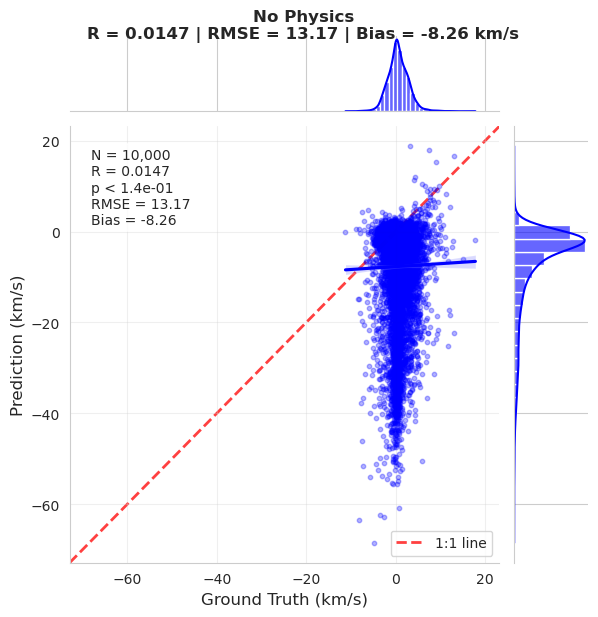


No Physics - Line-of-sight Velocity at log(τ)=0.0
  Pearson R:   0.0147 (p=1.42e-01)
  RMSE:        13.17 km/s
  Bias:        -8.26 km/s
  Samples:     10,000


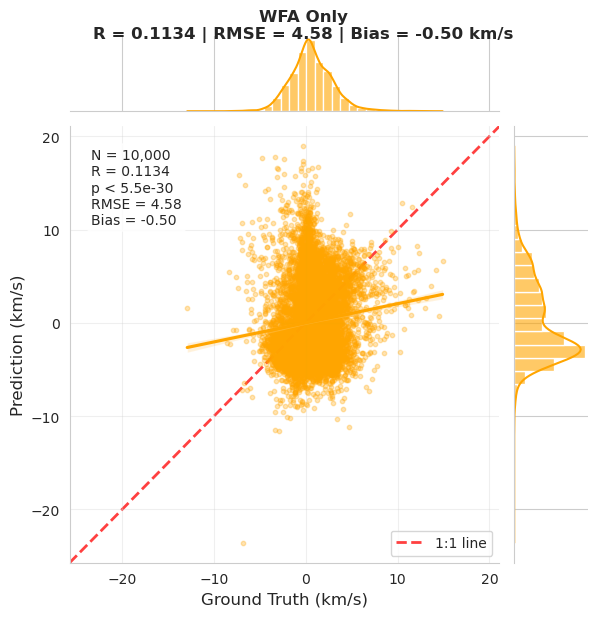


WFA Only - Line-of-sight Velocity at log(τ)=0.0
  Pearson R:   0.1134 (p=5.54e-30)
  RMSE:        4.58 km/s
  Bias:        -0.50 km/s
  Samples:     10,000


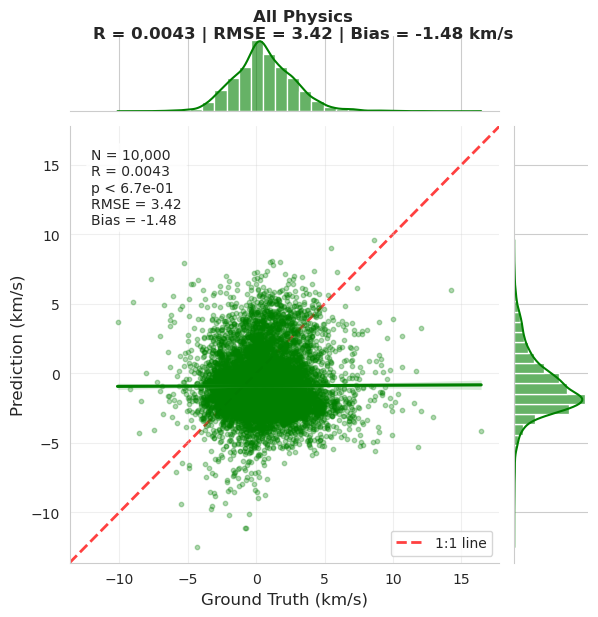


All Physics - Line-of-sight Velocity at log(τ)=0.0
  Pearson R:   0.0043 (p=6.68e-01)
  RMSE:        3.42 km/s
  Bias:        -1.48 km/s
  Samples:     10,000

Separate Jointplots: Bz


/tmp/ipykernel_1425124/2115631497.py:68: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


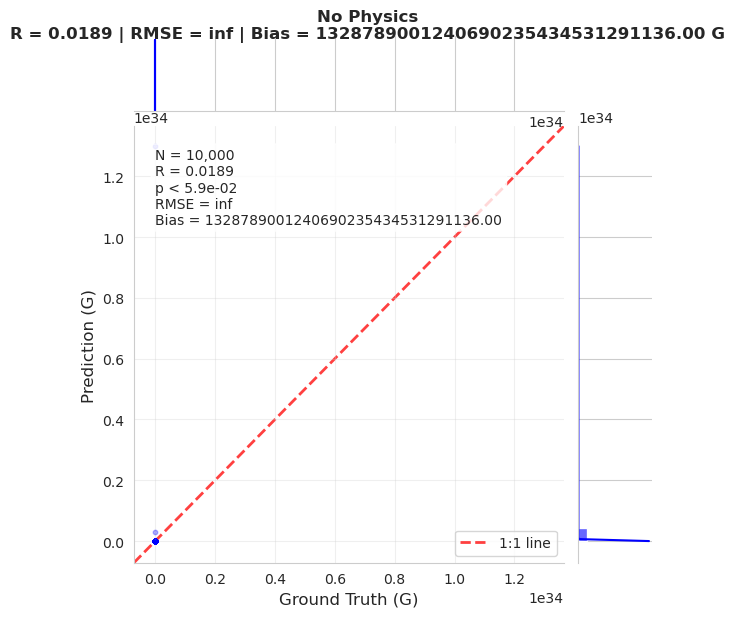


No Physics - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   0.0189 (p=5.93e-02)
  RMSE:        inf G
  Bias:        1328789001240690235434531291136.00 G
  Samples:     10,000


/tmp/ipykernel_1425124/2115631497.py:68: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))


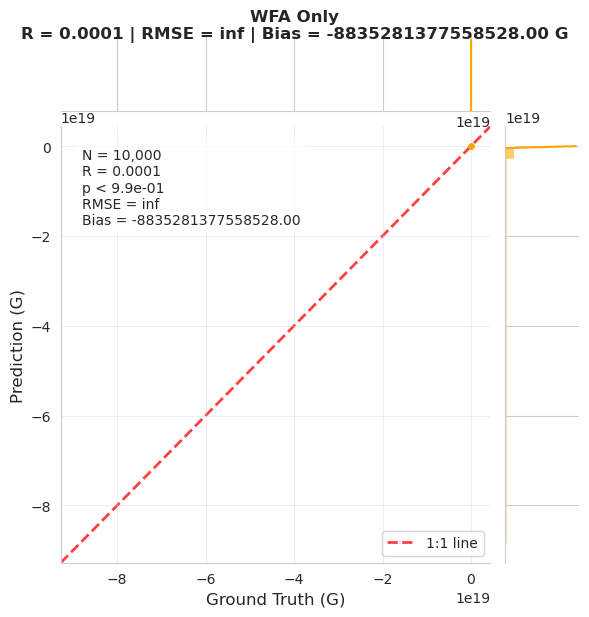


WFA Only - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   0.0001 (p=9.90e-01)
  RMSE:        inf G
  Bias:        -8835281377558528.00 G
  Samples:     10,000


/tmp/ipykernel_1425124/2115631497.py:68: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((pred_valid - gt_valid)**2))
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


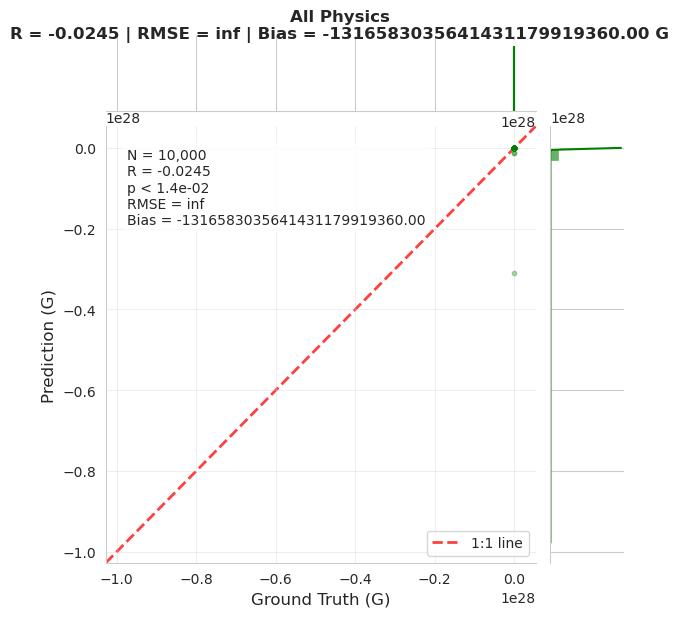


All Physics - Line-of-sight Magnetic Field at log(τ)=0.0
  Pearson R:   -0.0245 (p=1.45e-02)
  RMSE:        inf G
  Bias:        -1316583035641431179919360.00 G
  Samples:     10,000


In [101]:
# 1. Separate jointplots for each model
for param in ['T', 'Vz', 'Bz']:
    print(f"\n{'='*80}")
    print(f"Separate Jointplots: {param}")
    print(f"{'='*80}")
    plot_jointplot_comparison(
        all_predictions=all_predictions,
        ground_truth=modest.spinor_atm,
        mag_to_plot=param,
        od_val=0.0,
        logtau=logtau,
        n_samples=10000,
        kind='reg'  # Options: 'scatter', 'hex', 'kde', 'reg'
    )


Combined Jointplot: T


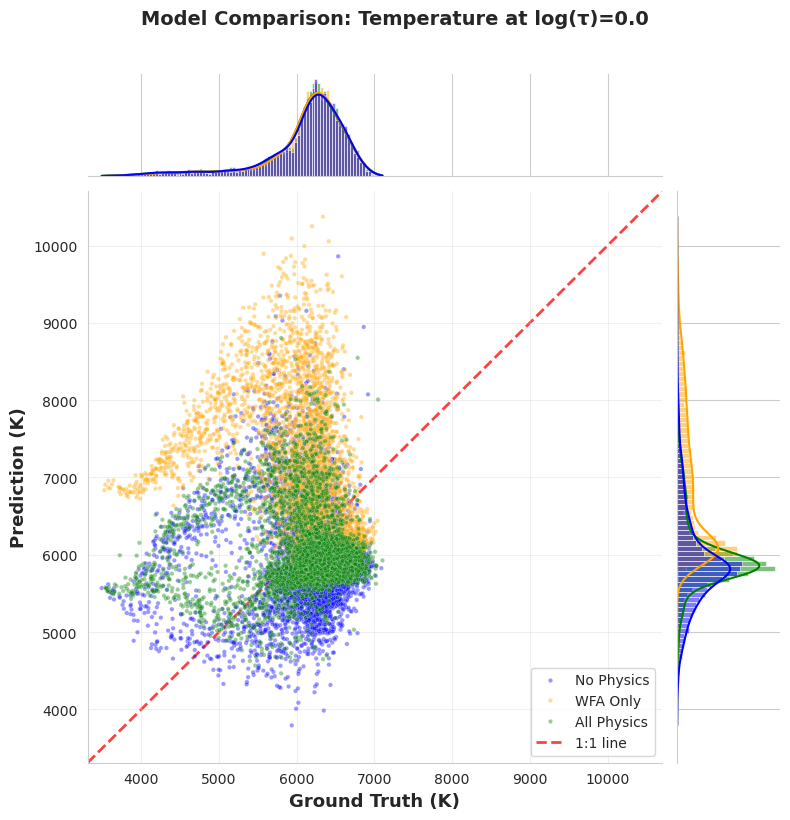


Combined Analysis: Temperature at log(τ)=0.0

No Physics:
  Pearson R:   -0.0079 (p=5.77e-01)
  RMSE:        885.62 K
  Bias:        -181.96 K
  Samples:     5,000

WFA Only:
  Pearson R:   -0.3989 (p=2.46e-190)
  RMSE:        1457.74 K
  Bias:        767.92 K
  Samples:     5,000

All Physics:
  Pearson R:   0.0222 (p=1.17e-01)
  RMSE:        742.75 K
  Bias:        -91.38 K
  Samples:     5,000


Combined Jointplot: Vz


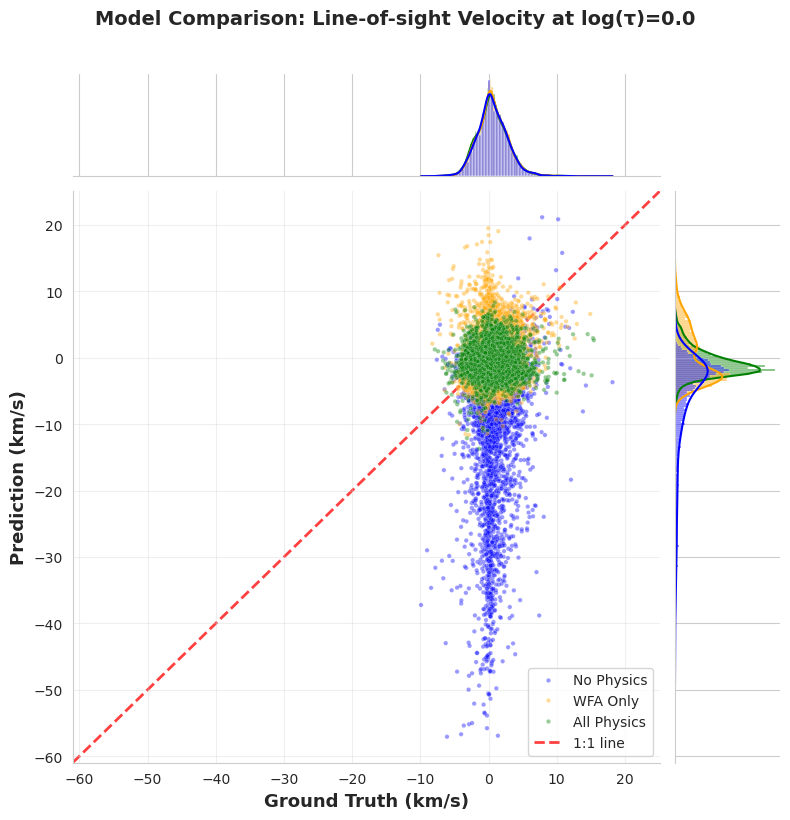


Combined Analysis: Line-of-sight Velocity at log(τ)=0.0

No Physics:
  Pearson R:   0.0514 (p=2.78e-04)
  RMSE:        13.06 km/s
  Bias:        -8.14 km/s
  Samples:     5,000

WFA Only:
  Pearson R:   0.1031 (p=2.66e-13)
  RMSE:        4.54 km/s
  Bias:        -0.51 km/s
  Samples:     5,000

All Physics:
  Pearson R:   0.0076 (p=5.92e-01)
  RMSE:        3.47 km/s
  Bias:        -1.48 km/s
  Samples:     5,000


Combined Jointplot: Bz


ValueError: Maximum allowed size exceeded

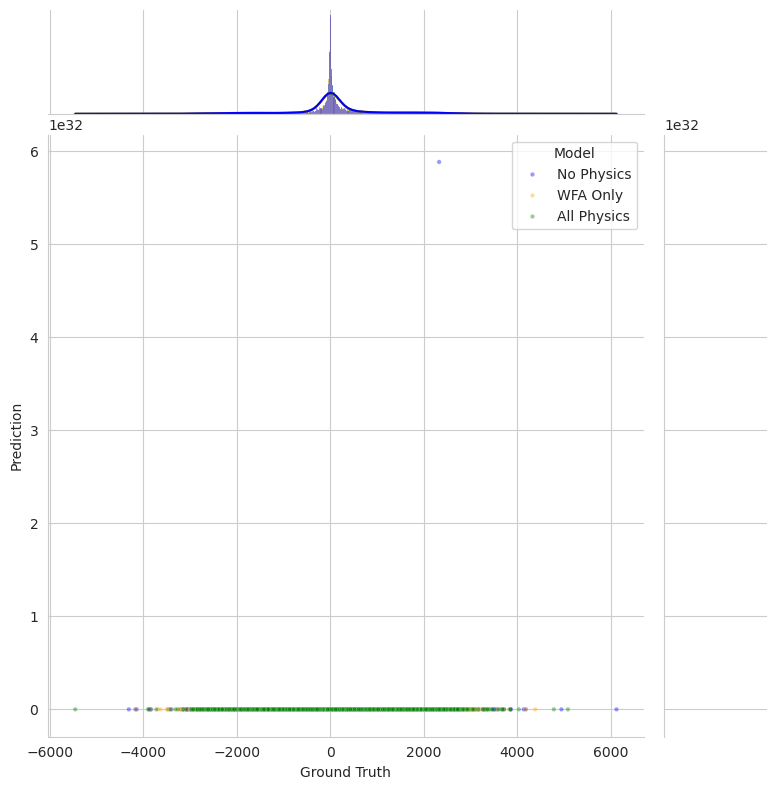

In [100]:
# 2. Combined jointplot with all models overlaid
for param in ['T', 'Vz', 'Bz']:
    print(f"\n{'='*80}")
    print(f"Combined Jointplot: {param}")
    print(f"{'='*80}")
    plot_combined_jointplot(
        all_predictions=all_predictions,
        ground_truth=modest.spinor_atm,
        mag_to_plot=param,
        od_val=0.0,
        logtau=logtau,
        n_samples=5000
    )

## 11. Error Analysis by Magnitude

In [85]:
def analyze_error_by_magnitude(
    all_predictions: Dict,
    ground_truth: dict,
    mag_to_analyze: str = "Bz",
    logtau: np.ndarray = None,
    od_val: float = 0.0,
    figsize: tuple = (18, 6),
    n_bins: int = 10,
    plot_counts: bool = True,
    percentile_lims: tuple = None,
    use_absolute: bool = False,
    rrmse_ylim: tuple = None
):
    """
    Analyze prediction error as a function of magnitude strength using bar plots.
    
    Parameters
    ----------
    all_predictions : Dict
        Dictionary of model predictions
    ground_truth : dict
        Ground truth SPINOR atmosphere
    mag_to_analyze : str
        Magnitude to analyze: 'T', 'Vz', or 'Bz'
    logtau : np.ndarray, optional
        Optical depth grid
    od_val : float
        Optical depth value to analyze
    figsize : tuple
        Figure size
    n_bins : int
        Number of bins for magnitude ranges
    percentile_lims : tuple, optional
        Percentile limits for x-axis (e.g., (1, 99))
    use_absolute : bool
        If True, bin by absolute values (default: False, uses signed values)
    rrmse_ylim : tuple, optional
        Y-axis limits for RRMSE percentage (e.g., (0, 50) for 0-50%)
        If None, uses automatic limits
    """
    from scipy.stats import binned_statistic
    
    # Configuration
    title_map = {"T": "Temperature", "Vz": "Line-of-sight Velocity", "Bz": "Line-of-sight Magnetic Field"}
    units_map = {"T": "K", "Vz": "km/s", "Bz": "G"}
    gt_key_mapping = {"T": "T", "Vz": "Vlos", "Bz": "Blos"}
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    if logtau is None:
        logtau = np.arange(-2, 0.1, 0.1)
    
    od_idx = np.argmin(np.abs(logtau - od_val))
    gt_data = ground_truth[gt_key_mapping[mag_to_analyze]][od_val]
    
    for i, (model_name, pred_data) in enumerate(all_predictions.items()):
        pred_mag = pred_data['mean'][mag_to_analyze][:, :, od_idx]
        error = np.abs(pred_mag - gt_data)
        
        # Flatten and filter NaNs
        gt_flat = gt_data.flatten()
        pred_flat = pred_mag.flatten()
        error_flat = error.flatten()
        valid = ~np.isnan(gt_flat) & ~np.isnan(pred_flat) & ~np.isnan(error_flat)
        
        # Use signed or absolute values for binning
        if use_absolute:
            gt_binning = np.abs(gt_flat[valid])
            xlabel_prefix = "|Ground Truth"
            xlabel_suffix = "|"
        else:
            gt_binning = gt_flat[valid]
            xlabel_prefix = "Ground Truth"
            xlabel_suffix = ""
        
        pred_valid = pred_flat[valid]
        error_valid = error_flat[valid]
        gt_valid = gt_flat[valid]
        
        # Compute binned statistics
        bin_means, bin_edges, bin_number = binned_statistic(
            gt_binning, error_valid, statistic='mean', bins=n_bins
        )
        bin_stds, _, _ = binned_statistic(
            gt_binning, error_valid, statistic='std', bins=n_bins
        )
        bin_counts, _, _ = binned_statistic(
            gt_binning, error_valid, statistic='count', bins=n_bins
        )
        
        # Compute RRMSE per bin
        bin_rrmse = np.zeros(n_bins)
        for j in range(n_bins):
            # Find data points in this bin
            in_bin = (gt_binning >= bin_edges[j]) & (gt_binning < bin_edges[j+1])
            if np.sum(in_bin) > 0:
                gt_bin = gt_valid[in_bin]
                pred_bin = pred_valid[in_bin]
                error_bin = error_valid[in_bin]
                
                # RMSE for this bin
                rmse_bin = np.sqrt(np.mean(error_bin**2))
                
                # Mean of ground truth in this bin (for normalization)
                # Use absolute value for normalization to avoid division by values near zero
                gt_mean_bin = np.mean(np.abs(gt_bin))
                
                # RRMSE for this bin
                if gt_mean_bin > 1e-10:
                    bin_rrmse[j] = rmse_bin / gt_mean_bin
                else:
                    bin_rrmse[j] = np.nan
            else:
                bin_rrmse[j] = np.nan
        
        # Compute bin centers and widths
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_widths = bin_edges[1:] - bin_edges[:-1]
        
        # Create bar plot with RRMSE
        bars = axes[i].bar(bin_centers, bin_rrmse * 100, width=bin_widths * 0.9,
                          color=pred_data['color'], alpha=0.7, 
                          edgecolor='black', linewidth=1.5)
        
        # Add count labels on top of bars
        if plot_counts:
            for j, (center, rrmse_val, count) in enumerate(zip(bin_centers, bin_rrmse, bin_counts)):
                if not np.isnan(rrmse_val) and count > 0:
                    # Adjust label position if it would be outside ylim
                    label_y = rrmse_val * 100
                    if rrmse_ylim is not None and label_y > rrmse_ylim[1]:
                        label_y = rrmse_ylim[1] - (rrmse_ylim[1] - rrmse_ylim[0]) * 0.05
                        axes[i].text(center, label_y, f'n={int(count)}',
                                ha='center', va='top', fontsize=8,
                                bbox=dict(boxstyle='round,pad=0.3', 
                                        facecolor='yellow', alpha=0.7),
                                color='red')  # Red to indicate clipped
                    else:
                        axes[i].text(center, label_y, f'n={int(count)}',
                                ha='center', va='bottom', fontsize=8,
                                bbox=dict(boxstyle='round,pad=0.3', 
                                        facecolor='white', alpha=0.7))
            
        # Formatting
        axes[i].set_xlabel(f"{xlabel_prefix} {title_map[mag_to_analyze]}{xlabel_suffix} [{units_map[mag_to_analyze]}]", 
                          fontsize=11, fontweight='bold')
        axes[i].set_ylabel("RRMSE [%]", fontsize=11, fontweight='bold')
        axes[i].set_title(f"{pred_data['label']}", fontsize=12, fontweight='bold')
        axes[i].grid(alpha=0.3, axis='y')
        
        # Set y-axis limits for RRMSE
        if rrmse_ylim is not None:
            axes[i].set_ylim(rrmse_ylim)
        
        # Set x-axis limits
        if percentile_lims is not None:
            axes[i].set_xlim([np.percentile(gt_binning, percentile_lims[0]), 
                             np.percentile(gt_binning, percentile_lims[1])])
        else:
            axes[i].set_xlim([bin_edges[0], bin_edges[-1]])
        
        # Add vertical line at zero if using signed values
        if not use_absolute and mag_to_analyze in ['Vz', 'Bz']:
            axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero')
        
        # Add statistics text box
        overall_mae = np.mean(error_valid)
        overall_rmse = np.sqrt(np.mean(error_valid**2))
        overall_rrmse = overall_rmse / np.mean(np.abs(gt_valid)) if np.mean(np.abs(gt_valid)) > 1e-10 else np.nan
        
        if not np.isnan(overall_rrmse):
            stats_text = f"MAE: {overall_mae:.2f} {units_map[mag_to_analyze]}\nRMSE: {overall_rmse:.2f} {units_map[mag_to_analyze]}\nRRMSE: {overall_rrmse*100:.2f}%"
        else:
            stats_text = f"MAE: {overall_mae:.2f} {units_map[mag_to_analyze]}\nRMSE: {overall_rmse:.2f} {units_map[mag_to_analyze]}\nRRMSE: N/A"
        
        axes[i].text(0.98, 0.98, stats_text,
                    transform=axes[i].transAxes,
                    fontsize=10, verticalalignment='top',
                    horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    binning_type = "Absolute" if use_absolute else "Signed"
    plt.suptitle(f"Prediction RRMSE vs {binning_type} {title_map[mag_to_analyze]} at log(τ)={od_val:.1f}", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics (same as before)
    print("\n" + "="*70)
    print(f"Error Analysis by {binning_type} {title_map[mag_to_analyze]} at log(τ)={od_val:.1f}")
    print("="*70)
    
    for model_name, pred_data in all_predictions.items():
        pred_mag = pred_data['mean'][mag_to_analyze][:, :, od_idx]
        error = np.abs(pred_mag - gt_data)
        
        gt_flat = gt_data.flatten()
        pred_flat = pred_mag.flatten()
        error_flat = error.flatten()
        valid = ~np.isnan(gt_flat) & ~np.isnan(pred_flat) & ~np.isnan(error_flat)
        
        if use_absolute:
            gt_binning = np.abs(gt_flat[valid])
        else:
            gt_binning = gt_flat[valid]
        
        pred_valid = pred_flat[valid]
        error_valid = error_flat[valid]
        gt_valid = gt_flat[valid]
        
        # Compute binned statistics
        bin_means, bin_edges, _ = binned_statistic(
            gt_binning, error_valid, statistic='mean', bins=n_bins
        )
        bin_counts, _, _ = binned_statistic(
            gt_binning, error_valid, statistic='count', bins=n_bins
        )
        
        print(f"\n{pred_data['label']}:")
        print("-" * 70)
        
        for j, (low, high, mean_err, counts) in enumerate(zip(bin_edges[:-1], bin_edges[1:], bin_means, bin_counts)):
            if not np.isnan(mean_err) and counts > 0:
                # Find errors in this bin
                in_bin = (gt_binning >= low) & (gt_binning < high)
                n_samples = np.sum(in_bin)
                
                if n_samples > 0:
                    gt_bin = gt_valid[in_bin]
                    pred_bin = pred_valid[in_bin]
                    error_bin = error_valid[in_bin]
                    
                    std_err = np.std(error_bin)
                    rmse_bin = np.sqrt(np.mean(error_bin**2))
                    gt_mean_bin = np.mean(np.abs(gt_bin))
                    
                    # Also report mean signed value for context
                    gt_mean_signed = np.mean(gt_bin)
                    
                    if gt_mean_bin > 1e-10:
                        rrmse_bin = rmse_bin / gt_mean_bin
                        if use_absolute:
                            print(f"  Bin {j+1}: |{low:8.2f}| - |{high:8.2f}| {units_map[mag_to_analyze]}  |  "
                                  f"N: {n_samples:,}  |  "
                                  f"MAE: {mean_err:8.2f} ± {std_err:6.2f}  |  "
                                  f"RRMSE: {rrmse_bin*100:6.2f}%")
                        else:
                            print(f"  Bin {j+1}: {low:8.2f} - {high:8.2f} {units_map[mag_to_analyze]}  |  "
                                  f"N: {n_samples:,}  |  "
                                  f"GT_mean: {gt_mean_signed:+8.2f}  |  "
                                  f"MAE: {mean_err:8.2f} ± {std_err:6.2f}  |  "
                                  f"RRMSE: {rrmse_bin*100:6.2f}%")
                    else:
                        print(f"  Bin {j+1}: {low:8.2f} - {high:8.2f} {units_map[mag_to_analyze]}  |  "
                              f"N: {n_samples:,}  |  "
                              f"MAE: {mean_err:8.2f} ± {std_err:6.2f}  |  "
                              f"RRMSE: N/A (GT too small)")
        
        # Overall statistics
        overall_mae = np.mean(error_valid)
        overall_rmse = np.sqrt(np.mean(error_valid**2))
        overall_rrmse = overall_rmse / np.mean(np.abs(gt_valid)) if np.mean(np.abs(gt_valid)) > 1e-10 else np.nan
        
        print(f"\n  Overall Statistics:")
        print(f"    Mean Absolute Error (MAE):  {overall_mae:.2f} {units_map[mag_to_analyze]}")
        print(f"    Root Mean Square Error:     {overall_rmse:.2f} {units_map[mag_to_analyze]}")
        if not np.isnan(overall_rrmse):
            print(f"    Relative RMSE (RRMSE):      {overall_rrmse:.4f} ({overall_rrmse*100:.2f}%)")
        else:
            print(f"    Relative RMSE (RRMSE):      N/A")
    
    print("\n" + "="*70)

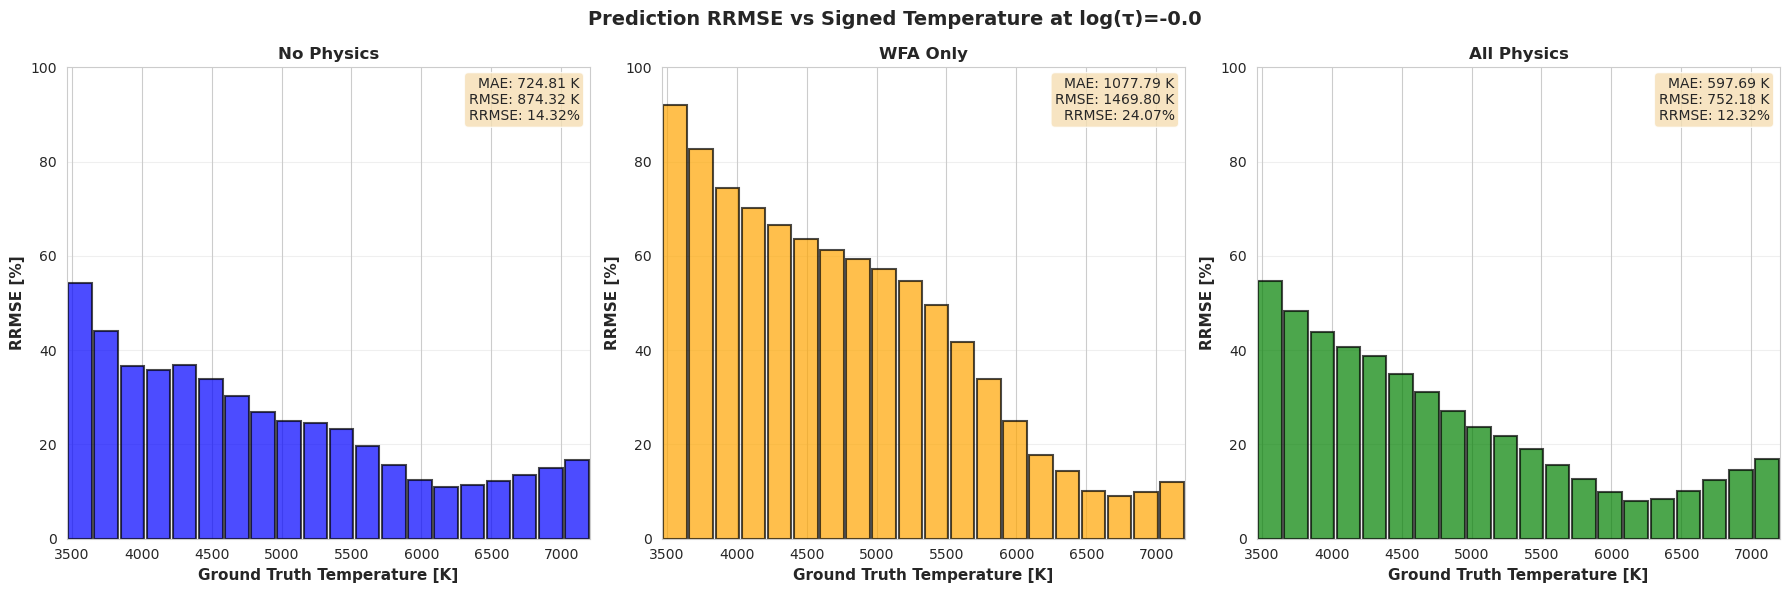


Error Analysis by Signed Temperature at log(τ)=-0.0

No Physics:
----------------------------------------------------------------------
  Bin 1:  3464.33 -  3651.41 K  |  N: 544  |  GT_mean: +3588.03  |  MAE:  1947.73 ±  86.34  |  RRMSE:  54.34%
  Bin 2:  3651.41 -  3838.50 K  |  N: 847  |  GT_mean: +3756.13  |  MAE:  1650.41 ± 161.52  |  RRMSE:  44.15%
  Bin 3:  3838.50 -  4025.58 K  |  N: 1,693  |  GT_mean: +3939.80  |  MAE:  1414.84 ± 266.18  |  RRMSE:  36.54%
  Bin 4:  4025.58 -  4212.67 K  |  N: 2,699  |  GT_mean: +4125.84  |  MAE:  1423.90 ± 398.43  |  RRMSE:  35.84%
  Bin 5:  4212.67 -  4399.76 K  |  N: 3,242  |  GT_mean: +4307.83  |  MAE:  1501.22 ± 508.70  |  RRMSE:  36.80%
  Bin 6:  4399.76 -  4586.84 K  |  N: 3,362  |  GT_mean: +4493.24  |  MAE:  1404.22 ± 584.22  |  RRMSE:  33.85%
  Bin 7:  4586.84 -  4773.93 K  |  N: 3,796  |  GT_mean: +4681.56  |  MAE:  1232.45 ± 691.44  |  RRMSE:  30.19%
  Bin 8:  4773.93 -  4961.02 K  |  N: 3,974  |  GT_mean: +4868.71  |  MAE:  1059.28

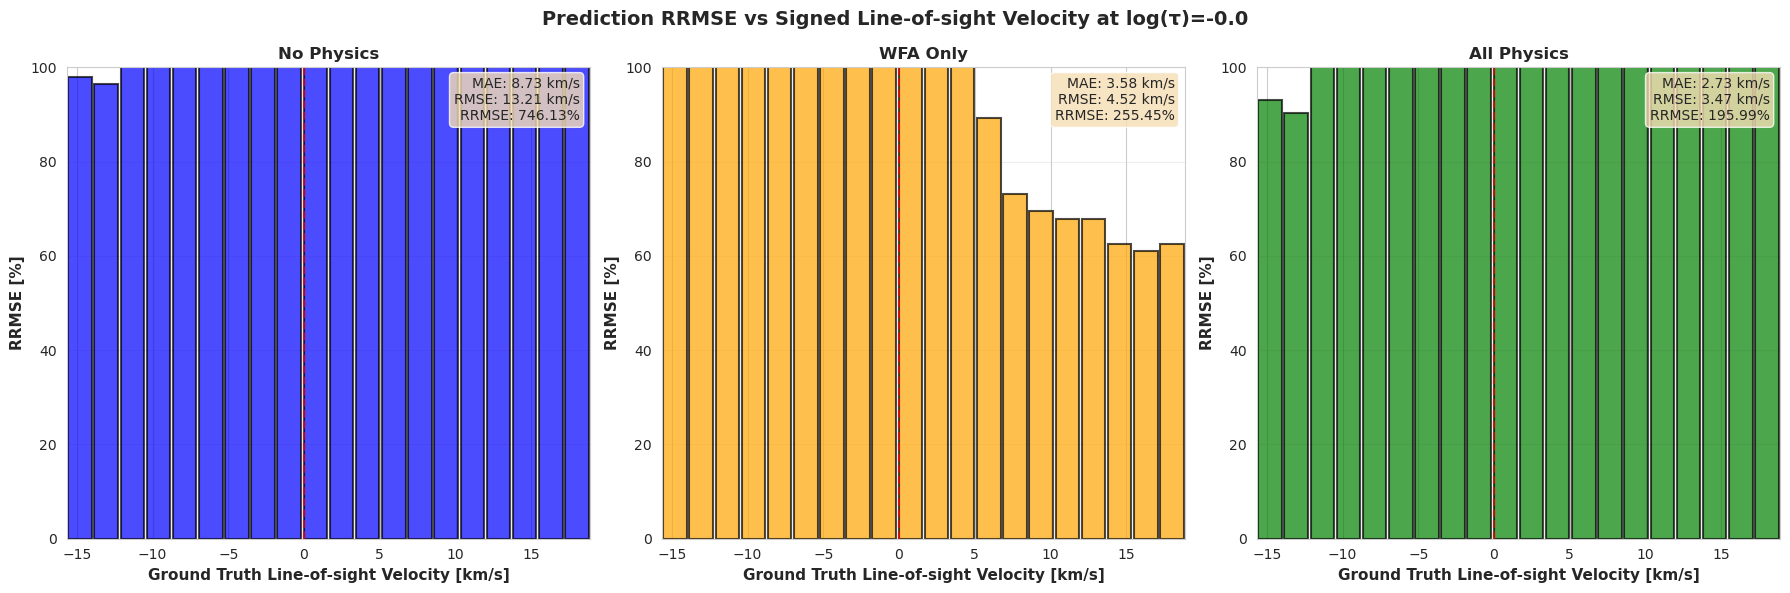


Error Analysis by Signed Line-of-sight Velocity at log(τ)=-0.0

No Physics:
----------------------------------------------------------------------
  Bin 1:   -15.65 -   -13.93 km/s  |  N: 1  |  GT_mean:   -15.65  |  MAE:    15.32 ±   0.00  |  RRMSE:  97.86%
  Bin 2:   -13.93 -   -12.20 km/s  |  N: 4  |  GT_mean:   -12.56  |  MAE:    12.11 ±   0.55  |  RRMSE:  96.46%
  Bin 3:   -12.20 -   -10.47 km/s  |  N: 17  |  GT_mean:   -11.07  |  MAE:    14.05 ±   8.97  |  RRMSE: 150.59%
  Bin 4:   -10.47 -    -8.75 km/s  |  N: 76  |  GT_mean:    -9.38  |  MAE:    14.17 ±   9.63  |  RRMSE: 182.72%
  Bin 5:    -8.75 -    -7.02 km/s  |  N: 305  |  GT_mean:    -7.72  |  MAE:    14.09 ±  11.76  |  RRMSE: 237.84%
  Bin 6:    -7.02 -    -5.29 km/s  |  N: 1,097  |  GT_mean:    -6.00  |  MAE:    12.95 ±  12.20  |  RRMSE: 296.51%
  Bin 7:    -5.29 -    -3.57 km/s  |  N: 6,047  |  GT_mean:    -4.15  |  MAE:     7.66 ±  10.61  |  RRMSE: 315.75%
  Bin 8:    -3.57 -    -1.84 km/s  |  N: 35,518  |  GT_mean:   

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_binned_statistic.py:609: RuntimeWarning: invalid value encountered in subtract
  delta = values[vv] - flatsum[binnumbers] / flatcount[binnumbers]
/tmp/ipykernel_1425124/4096869752.py:102: RuntimeWarning: overflow encountered in square
  rmse_bin = np.sqrt(np.mean(error_bin**2))
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1425124/4096869752.py:168: RuntimeWarning: overflow encountered in square
  overall_rmse = np.sqrt(np.mean(error_valid**2))


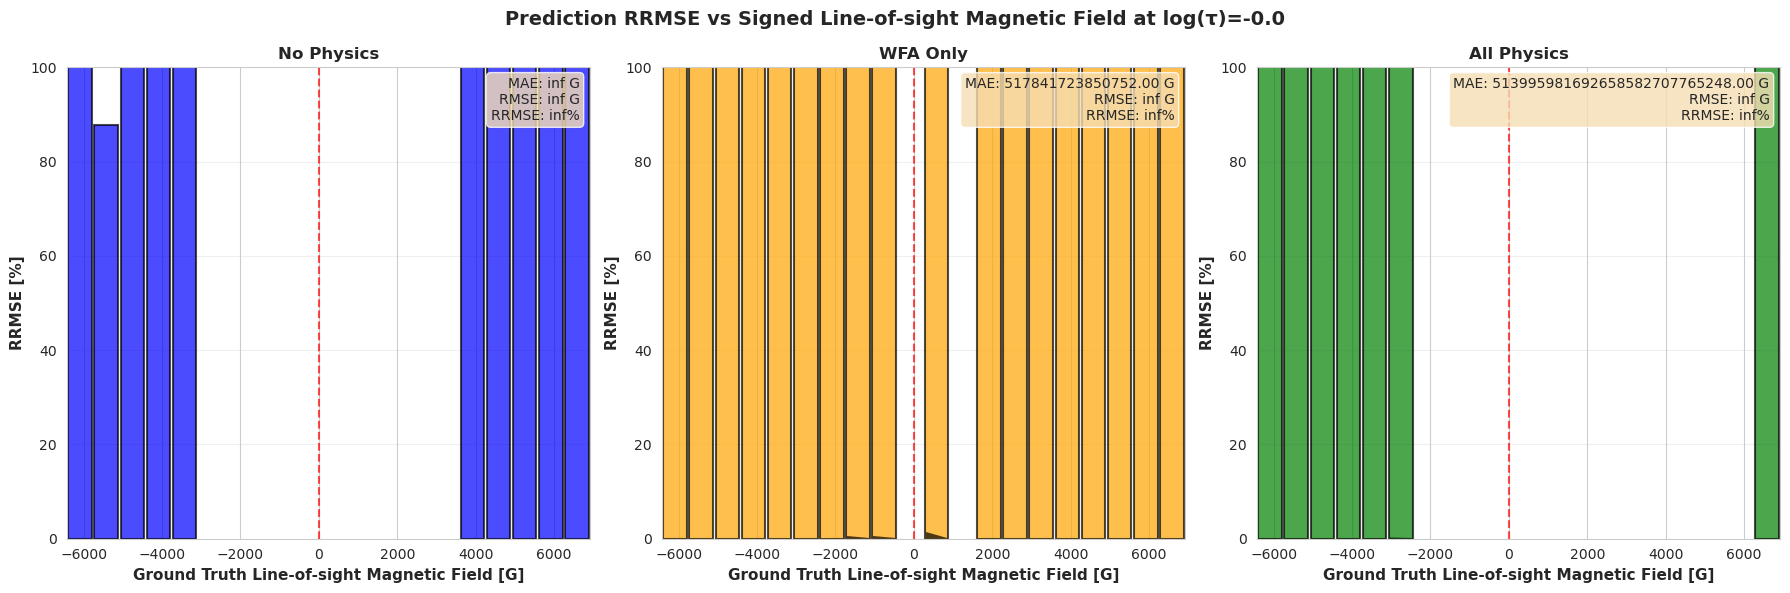


Error Analysis by Signed Line-of-sight Magnetic Field at log(τ)=-0.0

No Physics:
----------------------------------------------------------------------
  Bin 1: -6428.83 - -5761.55 G  |  N: 7  |  GT_mean: -6061.97  |  MAE: 33846.24 ± 72360.53  |  RRMSE: 1317.81%
  Bin 2: -5761.55 - -5094.27 G  |  N: 21  |  GT_mean: -5346.54  |  MAE:  4465.43 ± 1454.96  |  RRMSE:  87.84%
  Bin 3: -5094.27 - -4426.98 G  |  N: 37  |  GT_mean: -4762.73  |  MAE: 14782.87 ± 53587.88  |  RRMSE: 1167.18%
  Bin 4: -4426.98 - -3759.70 G  |  N: 136  |  GT_mean: -4029.58  |  MAE: 30484883.29 ± 353954240.00  |  RRMSE: 8816407.03%
  Bin 5: -3759.70 - -3092.42 G  |  N: 781  |  GT_mean: -3339.12  |  MAE: 97996723120.49 ± 2652905930752.00  |  RRMSE: 79503379200.00%
  Bin 6: -3092.42 - -2425.14 G  |  N: 4,382  |  GT_mean: -2679.17  |  MAE: 29416889184728904.00 ±    inf  |  RRMSE:    inf%
  Bin 7: -2425.14 - -1757.86 G  |  N: 11,539  |  GT_mean: -2064.11  |  MAE: 44724843643820448.00 ±    inf  |  RRMSE:    inf%
  Bin 8

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/tmp/ipykernel_1425124/4096869752.py:234: RuntimeWarning: overflow encountered in square
  rmse_bin = np.sqrt(np.mean(error_bin**2))
/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_1425124/4096869752.py:261: RuntimeWarning: overflow encountered in square
  overall_rmse = np.sqrt(np.mean(error_valid**2))


In [103]:
for param in ['T', 'Vz', 'Bz']:
    analyze_error_by_magnitude(
        all_predictions=all_predictions,
        ground_truth=modest.spinor_atm,
        mag_to_analyze=param,  # Choose: "T", "Vz", or "Bz"
        od_val=-0.0,
        logtau=logtau,
        n_bins=20,
        plot_counts=False,
        use_absolute=False,
        rrmse_ylim=(0, 100)
    )

## 12. Uncertainty Quantification Analysis

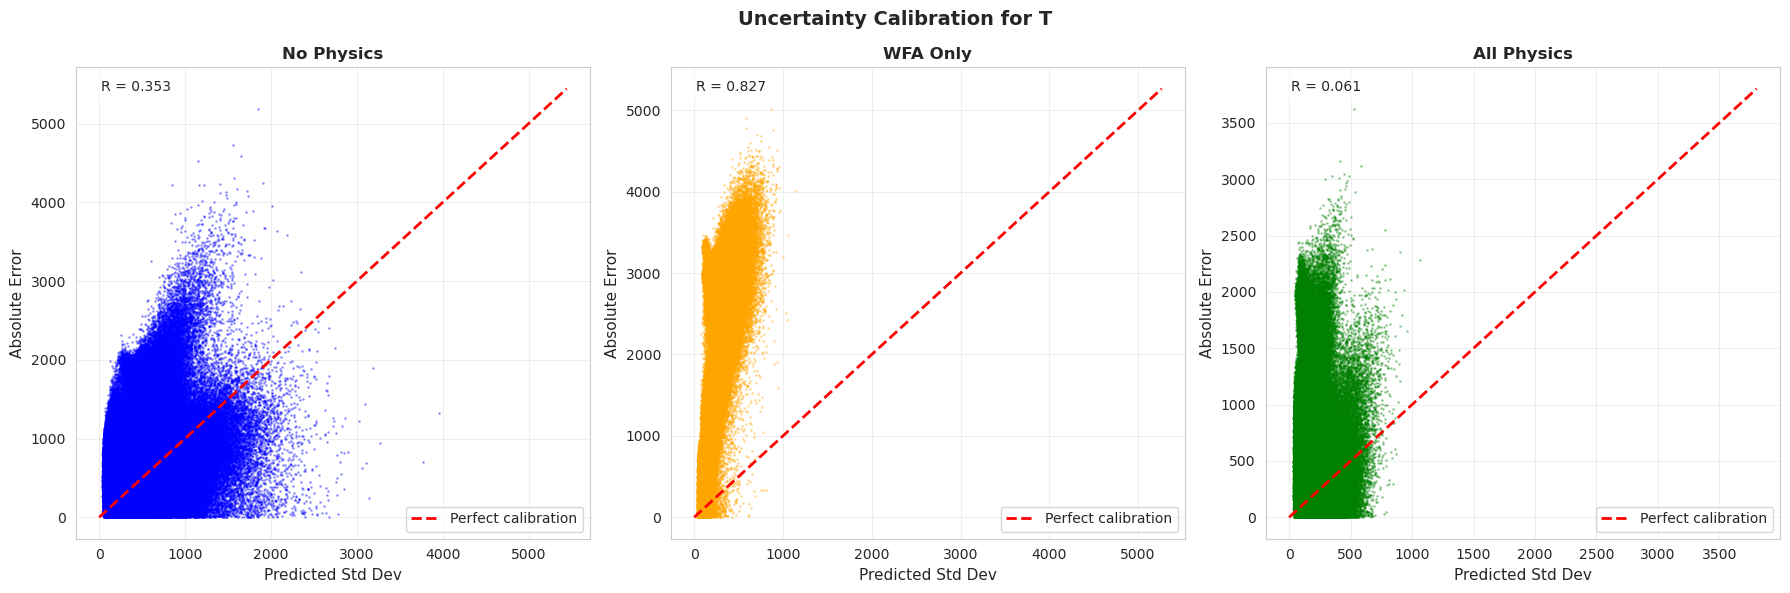

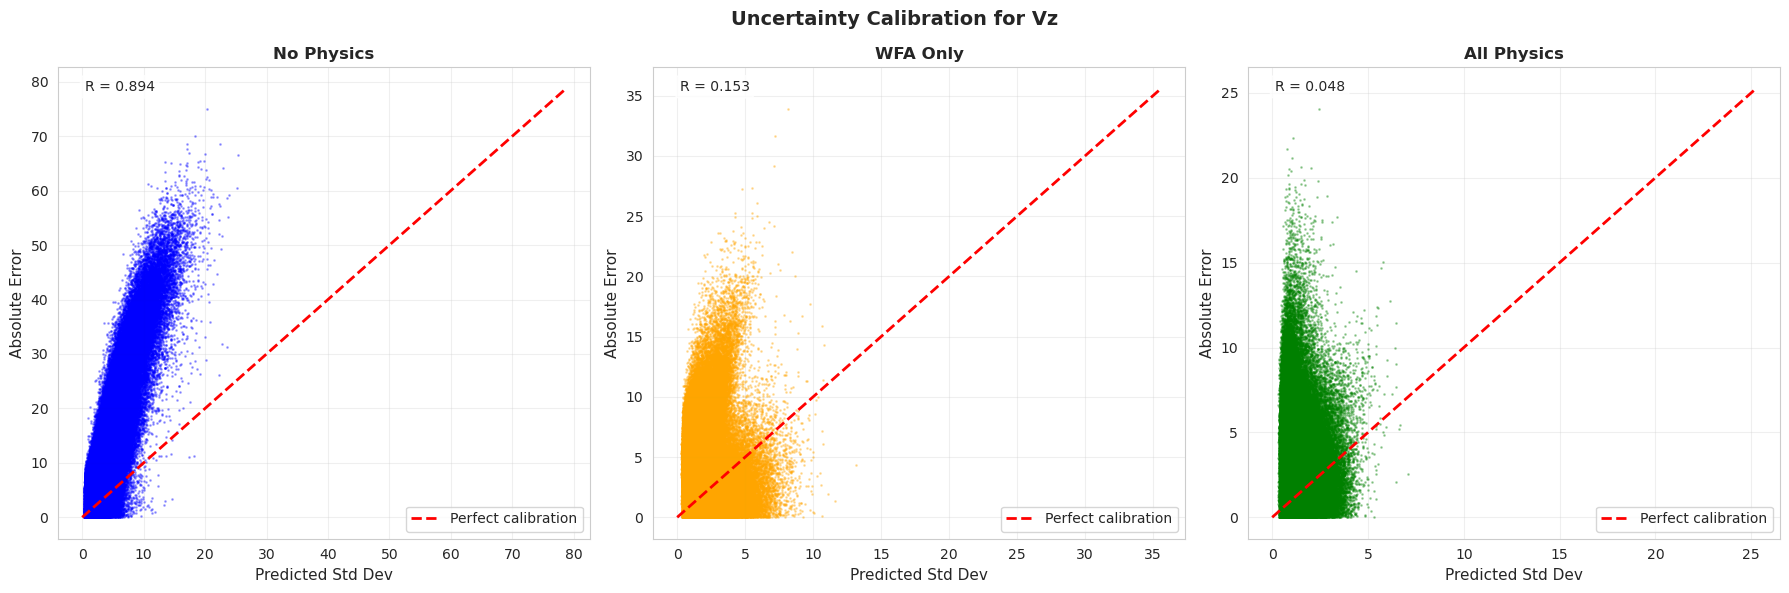

/homes/observatorio/juagudeloo/.conda/envs/pytorch_jupyter/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4623: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


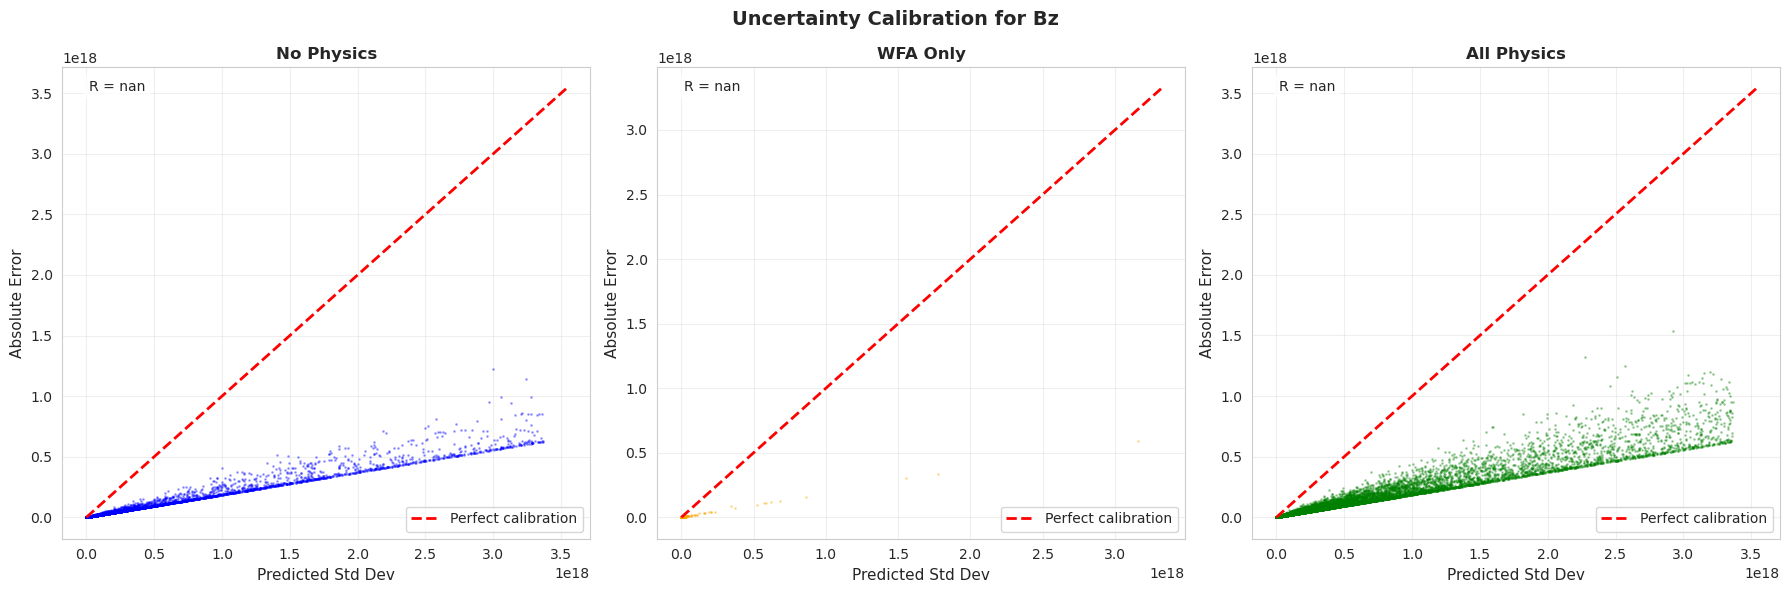

In [105]:
def plot_uncertainty_vs_error(
    all_predictions: Dict,
    ground_truth: dict,
    mag_to_plot: str = "Bz",
    od_val: float = 0.0,
    figsize: tuple = (18, 6)
):
    """Plot predicted uncertainty vs actual error to validate calibration."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    modest_key_mapping = {"T": "T", "Vz": "Vlos", "Bz": "Blos"}
    od_idx = np.argmin(np.abs(logtau - od_val))
    gt = ground_truth[modest_key_mapping[mag_to_plot]][od_val]
    
    for i, (model_name, pred_data) in enumerate(all_predictions.items()):
        pred_mean = pred_data['mean'][mag_to_plot][:, :, od_idx]
        pred_std = pred_data['std'][mag_to_plot][:, :, od_idx]
        
        error = np.abs(pred_mean - gt)
        
        # Flatten
        std_flat = pred_std.flatten()
        error_flat = error.flatten()
        valid = ~np.isnan(std_flat) & ~np.isnan(error_flat)
        
        # Scatter plot
        axes[i].scatter(std_flat[valid], error_flat[valid],
                       alpha=0.3, s=1, c=pred_data['color'])
        axes[i].set_xlabel("Predicted Std Dev", fontsize=11)
        axes[i].set_ylabel("Absolute Error", fontsize=11)
        axes[i].set_title(f"{pred_data['label']}", fontsize=12, fontweight='bold')
        axes[i].grid(alpha=0.3)
        
        # Add 1:1 line (perfect calibration)
        max_val = max(axes[i].get_xlim()[1], axes[i].get_ylim()[1])
        axes[i].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect calibration')
        
        # Compute calibration metric
        corr_calib, _ = pearsonr(std_flat[valid], error_flat[valid])
        axes[i].text(0.05, 0.95, f"R = {corr_calib:.3f}",
                    transform=axes[i].transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        axes[i].legend()
    
    plt.suptitle(f"Uncertainty Calibration for {mag_to_plot}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run uncertainty analysis
for param in ['T', 'Vz', 'Bz']:
    plot_uncertainty_vs_error(
        all_predictions=all_predictions,
        ground_truth=modest.spinor_atm,
        mag_to_plot=param,
        od_val=0.0
    )